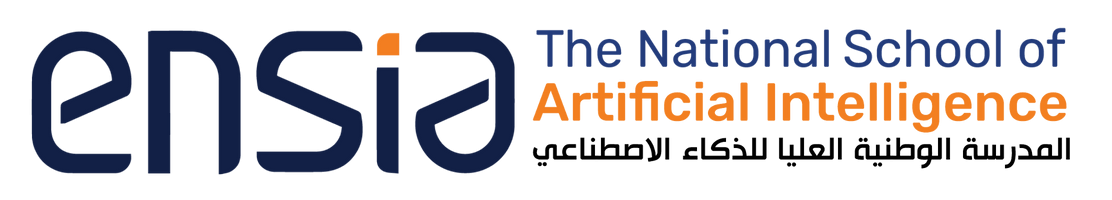

# 🎓 University Course-to-Room Allocator (UCRA)

### AI-Powered Optimization for Academic Scheduling

This notebook implements an intelligent system to solve the **University Course-to-Room Allocation** problem. Moving beyond manual scheduling, this application uses a hybrid AI approach to assign course events to rooms and timeslots while maximizing resource efficiency and faculty satisfaction.

----------

## 🚀 Overview

The UCRA system transforms the logistical challenge of campus resource management into a **Constraint Satisfaction Problem (CSP)** followed by **Metaheuristic Optimization**. The goal is to generate a schedule that is not only "valid" but "optimal."

### 🛠 The Two-Phase Approach

1.  **Phase 1: Initial Feasibility (CSP):** Uses systematic backtracking with the **Minimum Remaining Values (MRV)** heuristic to generate a valid starting state that respects all physical "Hard Constraints."
    
2.  **Phase 2: Optimization (Local Search):** Refines the initial schedule using advanced algorithms to minimize "Soft Constraint" penalties (e.g., wasted seats, travel distance).
    

----------

## 🔍 Optimization Algorithms

This notebook explores and compares four distinct local search strategies:

-   **Hill Climbing (HC):** Fast, greedy optimization towards the nearest local optimum.
    
-   **Random Restart Hill Climbing (RRHC):** Mitigates local optima by running multiple independent searches.
    
-   **Simulated Annealing (SA):** Uses a probabilistic cooling schedule to escape local optima and find global excellence.
    
-   **Tabu Search (TS):** Utilizes "memory" (a Tabu list) to prevent cycling and force exploration of new search spaces.
    

----------

## ⚖️ Constraints & Objectives

**Hard Constraints (Must be Met)**

**Soft Constraints (Optimization Goals)**

No double-booking (Rooms, Groups, Teachers)

Minimize wasted seating capacity

Room capacity $\ge$ Enrollment

Maximize Room Stability (same room for all lectures)

Room type compatibility

Minimize gaps in teacher/student schedules

Mandatory consecutive lecture structures

Prefer morning slots for core lectures

----------

## 📊 Key Metrics

The final output provides a visual dashboard including:

-   **Room Occupancy Heatmaps** to identify infrastructure bottlenecks.
    
-   **Professor Schedules** to ensure quality-of-life optimization.
    
-   **Efficiency Scores** compared against manual baseline scheduling.

### 📦 Setup

Run this command to install the necessary dependencies:

```bash
pip install streamlit numpy matplotlib pandas

```

In [1]:
pip install streamlit numpy matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
from math import exp
import random
from collections import deque
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from IPython.display import Image, display

## 🛠️ The Constraint Engine: Logic & Implementation

The `Constraints` class serves as the "referee" of our optimization system. It evaluates how well a specific schedule assignment performs against both physical requirements and academic preferences.

----------

### 1. The "Lookup Table" Strategy ⚡

Instead of re-scanning the entire dataset for every check, the engine uses a **preprocessing phase** (`_build_lookup_tables`).

-   **Efficiency:** It transforms the global state into resource-centric dictionaries (e.g., `slot_to_rooms`, `slot_to_teachers`).
    
-   **Speed:** This allows the algorithm to detect double-bookings in $O(1)$ time by checking if a resource appears more than once in a specific slot's list.
    

----------

### 2. Hard Constraints (The "Deal-Breakers") 🚫

These are non-negotiable physical limits. If a single hard constraint is violated, the schedule is considered **invalid**.

-   **Double-Booking:** Ensures no room, student group, or professor is in two places at once using set-based uniqueness checks.
    
-   **Suitability:** Validates that the room's **Capacity** exceeds the student headcount and the **Room Type** (Lab vs. Lecture) matches the event's needs.
    
-   **Workload:** Prevents student burnout by enforcing a maximum of **3 consecutive slots** without a break.
    

----------

### 3. Soft Constraints (The "Quality of Life" Metrics) 🌟

Soft constraints define what makes a schedule "good" rather than just "legal." Each violation adds a **penalty score** multiplied by a specific **weight**.

**Constraint**

**Objective**

**Wasted Seats**

Minimizes the gap between room capacity and enrollment to maximize utility.

**Room Changes**

Calculates the "geographical cost" of moving between floors or zones between classes.

**Gap Minimization**

Reduces "dead time" in schedules while respecting necessary lunch breaks.

**Morning Lectures**

Incentivizes placing core lectures earlier in the day when focus is highest.

**Teacher Days**

Attempts to condense a professor's sessions into fewer days to respect their research time.

----------

### 4. Mathematical Evaluation 🧮

The engine calculates the total penalty $P$ using a weighted sum:

$$P(S) = \sum (Weight_{i} \times Violation_{i})$$

This allows the **Simulated Annealing** and **Hill Climbing** algorithms to "feel" the search space, moving away from high-penalty configurations toward an optimized equilibrium.


In [3]:
class Constraints:
    # includes the constraints functions, seperated for clean structure
    def __init__(self, problem):
        self.problem = problem
    
    # build lookup tables once before looping, then check per constraint.
    def _build_lookup_tables(self, state):
        """
        Preprocesses the current schedule state into resource-centric lookup tables 
        for highly efficient constraint evaluation.

        Args:
            state (dict): The current assignment mapping event_id -> (roomid, slot).

        Returns:
            tuple: Four dictionaries mapping slots to rooms, groups, and teachers, 
                   plus a mapping of teachers to their assigned events.
        """
        from collections import defaultdict
        slot_to_rooms    = defaultdict(list)  
        slot_to_groups   = defaultdict(list)  
        slot_to_teachers = defaultdict(list)
        teacher_events   = defaultdict(list) 

        for event_id, (roomid, slot) in state.items():
            event = self.problem.events_by_id[event_id]
            teacher_id = event["teacher_id"]

            slot_to_rooms[slot].append(roomid)
            slot_to_teachers[slot].append(teacher_id)
            teacher_events[teacher_id].append(event_id)

            if event["type_id"] == 1: 
                for gid in self.problem.section_to_group[event["target_id"]]:
                    slot_to_groups[slot].append(gid)
            else:                      
                slot_to_groups[slot].append(event["target_id"])

        return slot_to_rooms, slot_to_groups, slot_to_teachers, teacher_events
    
    # Hard constraints methods
    # DOUBLE BOOKING

    def NO_ROOM_DOUBLE_BOOKING(self, slot_to_rooms, count=True):
        """
        Checks if any room is assigned to more than one event during the same timeslot.

        Args:
            slot_to_rooms (dict): Mapping of timeslots to lists of assigned room IDs.
            count (bool): If True, returns the total violation count. If False, returns False on the first violation.

        Returns:
            int | bool: The number of violations, or a boolean indicating validity.
        """
        violations = 0
        for slot, rooms in slot_to_rooms.items():
            v = len(rooms) - len(set(rooms))
            if not count and v > 0: return False
            violations += v
        return violations if count else True

    def NO_GROUP_DOUBLE_BOOKING(self, slot_to_groups, count=True):
        """
        Checks if any student group is scheduled for multiple events during the same timeslot.

        Args:
            slot_to_groups (dict): Mapping of timeslots to lists of assigned group IDs.
            count (bool): If True, returns the total violation count. If False, returns False on the first violation.

        Returns:
            int | bool: The number of violations, or a boolean indicating validity.
        """
        violations = 0
        for slot, groups in slot_to_groups.items():
            v = len(groups) - len(set(groups))
            if not count and v > 0: return False
            violations += v
        return violations if count else True

    def NO_TEACHER_DOUBLE_BOOKING(self, slot_to_teachers, count=True):
        """
        Checks if any teacher is scheduled to teach multiple events during the same timeslot.

        Args:
            slot_to_teachers (dict): Mapping of timeslots to lists of assigned teacher IDs.
            count (bool): If True, returns the total violation count. If False, returns False on the first violation.

        Returns:
            int | bool: The number of violations, or a boolean indicating validity.
        """
        violations = 0
        for slot, teachers in slot_to_teachers.items():
            v = len(teachers) - len(set(teachers))
            if not count and v > 0: return False
            violations += v
        return violations if count else True

    # ROOM SUITABILITY

    def ROOM_CAPACITY_GEQ_HEADCOUNT(self, state, count=True):
        """
        Ensures the assigned room's capacity is greater than or equal to the event's student headcount.

        Args:
            state (dict): The current schedule assignment.
            count (bool): If True, returns the violation count. If False, returns False on the first violation.

        Returns:
            int | bool: The number of violations, or a boolean indicating validity.
        """
        violations = 0
        for event_id, (roomid, slot) in state.items():
            event = self.problem.events_by_id[event_id]
            room  = self.problem.rooms_by_id[roomid]
            if room["capacity"] < event["headcount"]:
                if not count: return False
                violations += 1
        return violations if count else True

    def MATCH_ROOM_TYPE(self, state, count=True):
        """
        Ensures the assigned room type matches the required room type for the event (e.g., lecture hall vs lab).

        Args:
            state (dict): The current schedule assignment.
            count (bool): If True, returns the violation count. If False, returns False on the first violation.

        Returns:
            int | bool: The number of violations, or a boolean indicating validity.
        """
        violations = 0
        for event_id, (roomid, slot) in state.items():
            event = self.problem.events_by_id[event_id]
            room  = self.problem.rooms_by_id[roomid]
            if room["room_type_id"] != event["required_room_type_id"]:
                if not count: return False
                violations += 1
        return violations if count else True

    # SCHEDULING STRUCTURE


    # this constraint is NOT well-written + the functionality is implemented in soft constraints => removed for now


    def MAX_CONSECUTIVE_STUDENT_SLOTS_3(self, state, count=True):
        """
        Ensures no student group is scheduled for more than 3 consecutive timeslots without a break.

        Args:
            state (dict): The current schedule assignment.
            count (bool): If True, returns the violation count. If False, returns False on the first violation.

        Returns:
            int | bool: The number of violations, or a boolean indicating validity.
        """
        from collections import defaultdict
        group_day_slots = defaultdict(lambda: defaultdict(set))
        for event_id, (roomid, slot) in state.items():
            event = self.problem.events_by_id[event_id]
            day, time = slot // 6, slot % 6
            groups = (self.problem.section_to_group[event["target_id"]]
                    if event["type_id"] == 1 else [event["target_id"]])
            for gid in groups:
                group_day_slots[gid][day].add(time)

        violations = 0
        for gid, days in group_day_slots.items():
            for day, times in days.items():
                sorted_times = sorted(times)
                run = max_run = 1
                for k in range(1, len(sorted_times)):
                    run = run + 1 if sorted_times[k] == sorted_times[k-1] + 1 else 1
                    max_run = max(max_run, run)
                if max_run > 3:
                    if not count: return False
                    violations += 1
        return violations if count else True

    # soft constraints methods

    # external constraints
    def SIMILAR_ACTIVITIES(self, state, weight):
        from collections import defaultdict

        course_slots = defaultdict(list)
        # O(n)
        for event_id, (roomid, slot) in state.items():
            event_data = self.problem.events_by_id[event_id]
            if event_data["type_id"] != 1: continue
            course_slots[event_data["course_name"]].append(slot)

        non_similar = 0
        for c, s in course_slots.items():
            if len(s) < 2: continue # only one section
            # check for evey pair of secrions (useful if ensia will have many per year)
            # O(k^2) where k is section count which is 2-3 so not costly
            for i in range(len(s)):
                for j in range(i+1, len(s)):
                    diff = abs(s[i] - s[j])
                    same_day = (s[i] // 6) == (s[j] // 6)
                    if not (diff == 1 and same_day):
                        non_similar += 1
        return non_similar * weight

    def MINIMIZE_WASTED_SEATS(self, state, weight):
        # O(n) per call
        wasted = 0
        for event_id, (roomid, slot) in state.items():
            event_data = self.problem.events_by_id[event_id]
            room_data = self.problem.rooms_by_id[roomid]
            wasted += (room_data["capacity"] - event_data["headcount"]) / room_data["capacity"] # take the percentage wasted 
        return wasted * weight
    
    def SEPARATE_LECTURE_PRACTICE(self, state, weight=1.0, count=True):
        """
        Prevents scheduling a lecture and a practice session for the same course and group on the same day.

        Args:
            state (dict): The current schedule assignment.
            count (bool): If True, returns the violation count. If False, returns False on the first violation.

        Returns:
            int | bool: The number of violations, or a boolean indicating validity.
        """
        from collections import defaultdict
        key_to_types = defaultdict(list)
        for event_id, (roomid, slot) in state.items():
            event = self.problem.events_by_id[event_id]
            day   = slot // 6
            groups = (self.problem.section_to_group[event["target_id"]]
                    if event["type_id"] == 1 else [event["target_id"]])
            for gid in groups:
                key_to_types[(gid, event["course_name"], day)].append(event["type_id"])

        violations = 0
        for (gid, course, day), types in key_to_types.items():
            if any(t == 1 for t in types) and any(t != 1 for t in types):
                if not count: return False
                violations += 1
        return violations * weight

    # general constraints
    def MORNING_LECTURES(self, event, roomid, slot, weight):
        # give a penalty as the lectures go to the afternoon
        parameter = 0
        time = slot % 6
        if time == 0 or time == 1: return 0
        match time:
            case 2: parameter = 1
            case 3: parameter = 1.5
            case 4: parameter = 2
            case 5: parameter = 2.5
        return parameter * weight

    # group an teacher constraints
    def MINIMIZE_GAPS(self, schedule, weight):
        gaps = 0
        days_active = {0: [], 1: [], 2: [], 3: [], 4: []}
        for room, slot in schedule: days_active[slot // 6].append((room, slot % 6))
        # traversing sessions to look for gaps
        for day, classes in days_active.items():
            classes.sort(key=lambda x: x[1])
            for i in range(len(classes) - 1):
                time1 = classes[i][1]
                time2 = classes[i+1][1]
                diff = time2 - time1  # the diffrence between any two session
                if diff <= 1: continue # no gaps
                if diff == 2 and (time2 == 2 or time2 == 5): gaps += 1 # penalize one session gaps that doesn't fall in lunch break
                elif diff == 3 and time2 != 4: gaps += 1 # penalize two session gaps unless thay are in the break period 11:50-15:00
                else: gaps += 1.5 # penalize more the 4 and 5 session gaps
        return gaps * weight

    def AVOID_THURSDAY_AFTERNOON(self, schedule, weight):
        thursday_afternoon = {27, 28, 29}
        slots = [0, 0, 0]
        for room, slot in schedule:
            if slot in thursday_afternoon:
                slots[slot - 27] = 1
        return (slots[0] + 2 * slots[1] + 3 * slots[2]) * weight

    def AVOID_LAST_SLOT(self, schedule, weight):
        count = 0
        for room, slot in schedule:
            if slot % 6 == 5: count += 1
        return count * weight

    def MINIMIZE_ROOM_CHANGES(self, schedule, weight):
        room_change_cost = 0
        days_active = {0: [], 1: [], 2: [], 3: [], 4: []}
        for room, slot in schedule: days_active[slot // 6].append((room, slot % 6))
        # traversing sessions to look for consecutive sessions
        for day, classes in days_active.items():
            classes.sort(key=lambda x: x[1])
            for i in range(len(classes) - 1):
                room1, time1 = classes[i]
                room2, time2 = classes[i+1]
                diff = time2 - time1  # the diffrence between any two session
                if diff != 1: continue
                if room1 == room2: continue # 0 cost for staying at the same room
                # load rooms data
                room1_data = self.problem.rooms_by_id[room1]
                room2_data = self.problem.rooms_by_id[room2]

                r1_type, r1_floor = room1_data["room_type_id"], room1_data["floor"]
                r2_type, r2_floor = room2_data["room_type_id"], room2_data["floor"]
                # we compute the cost to travel from room1 to room2
                if r1_type == r2_type and r1_floor == r2_floor: room_change_cost += 0.5  #same zone
                elif r1_type != r2_type and r1_floor != r2_floor: room_change_cost += 2 # totaly different zone
                else: room_change_cost += 1 # partially different zone

        return room_change_cost * weight

    def MINIMIZE_TEACHER_DAYS(self, schedule, weight):
        days_active = {0: [], 1: [], 2: [], 3: [], 4: []}
        for room, slot in schedule: days_active[slot // 6].append((room, slot % 6))
        num_days = sum(1 for day in days_active.values() if day)
        num_sessions = sum(len(day) for day in days_active.values())
        if num_days < num_sessions // 3: return 0
        return weight * (num_days + 1 - (num_sessions // 3)) # the penalty increases with every additional day



## 🧠 The Problem Model: State & Strategy

The `EnsiaProblem` class acts as the central "brain" of the application. It encapsulates the data, the rules of the search space, and the mechanics of moving between different schedule configurations.

----------

### 1. State Representation: The Dictionary Map 🗺️

The "State" is the most critical data structure. It is represented as a **Python Dictionary**:

> **`{ event_id : (room_id, timeslot) }`**

-   **Why a dictionary?** It allows for **$O(1)$ constant-time lookups**. Whether checking a teacher’s schedule or a room’s availability, we can instantly access the assignment without looping through lists.
    
-   **The Search Space:** With 30 available timeslots ($5 \text{ days} \times 6 \text{ slots}$) per room, the number of possible combinations is astronomical.
    

----------

### 2. Generating the Initial State (CSP Backtracking) 🧱

Before optimization begins, we need a valid starting point. The `generate_valid_state` method uses **Backtracking with MRV (Minimum Remaining Values)**:

-   **Heuristic:** It picks the "most constrained" event first (the one with the fewest legal room/slot options).
    
-   **Pruning:** It removes invalid options from the "domain" of future events immediately after every assignment, preventing the algorithm from exploring doomed branches of the search tree.
    
-   **Divide & Conquer:** To ensure speed, it generates schedules **year-by-year**, ensuring that Year 1 classes don't conflict with Year 2.
    

----------

### 3. Neighbor Operators: The "Move" Pipeline 🔄

To improve the schedule, the AI must "tweak" it. The `pipeline_generate_neighbors` function combines several mathematical operators to explore the search space:

-   **Relocate:** Picks an event and moves it to a completely different, compatible (Room, Slot) pair.
    
-   **Swap:** Exchange the timeslots of two events while keeping them in their assigned rooms.
    
-   **Shift:** Slide events forward or backward within the same day to fill gaps or avoid late-afternoon slots.
    

**Crucially**, these operators are **constraint-aware**; they pre-screen moves to ensure we never break a hard constraint (like capacity) during the optimization phase.

----------

### 4. The Evaluation Function (Objective) 📉

The `evaluate()` method calculates the "Fitness" of a schedule. It aggregates penalties from the `Constraints` class into a weighted score:

$$Cost = (0.6 \times \text{Group Penalty}) + (0.4 \times \text{Professor Penalty}) + \text{General Costs}$$

The goal of our search algorithms (Hill Climbing, Simulated Annealing) is to navigate the state space to find the **global minimum** of this function.

In [4]:
# we comment the iport files since they live in the same file now ...
# from contraints import *
from collections import defaultdict
import copy 
import random
import json
import os

class Problem:
    pass

class EnsiaProblem(Problem):
    def __init__(self, dataset, cspmethod="global_search"):
        super().__init__()

        data = self.load_data(dataset)
        self.rooms = data[0]
        self.events = data[3]
        self.groups = data[2]
        self.teachers = data[5]
        self.section_to_group = {section["id"] : [] for section in data[1]}
        for group in self.groups: self.section_to_group[group["section_id"]].append(group["id"])
        self.events_by_id = {e["id"]: e for e in self.events}
        self.rooms_by_id  = {r["id"]:  r for r in self.rooms}
        self.groups_by_id  = {r["id"]:  r for r in self.groups}
        self.teachers_by_id = {t["id"]:  t for t in self.teachers}

        slots = []
        for r in self.rooms:
            for t in range(30):
                slots.append((r["id"], t))
        self.slots = slots
        
        self.hard_constraints_list = data[4].get("hard", [])
        self.soft_constraints_list = data[4].get("soft", [])

        self.constraint_obj = Constraints(self)

        self._lec_counts = defaultdict(int)
        for e in self.events:
            if e["type_id"] == 1:
                self._lec_counts[(e["course_name"], e["target_id"])] += 1

        if cspmethod == "local_search":
            self.state = self.generate_random_state()
        else:
            if cspmethod != "global_search": 
                print("invalid csp method, redirecting to GS csp ...\n")
            self.state = self.generate_valid_state()

    def load_data(self, filename):
        if not os.path.exists(filename):
            raise FileNotFoundError(f"Dataset file {filename} not found.")
        
        with open(filename, 'r', encoding='utf-8') as f:
            raw_data = json.load(f)
        
        return [
            raw_data.get("rooms", []),
            raw_data.get("sections", []),
            raw_data.get("groups", []),
            raw_data.get("activities", []),
            raw_data.get("constraints", {}),
            raw_data.get("teachers", {})
        ]

    def _is_room_compatible(self, room_id, event_id):
        """
        Returns True iff the room satisfies the event's hard structural
        requirements (type match + capacity).  Used by every move operator
        to pre-screen rooms in O(1) instead of running the full is_consistent
        scan for a change that is guaranteed to violate those two constraints.
        """
        room  = self.rooms_by_id[room_id]
        event = self.events_by_id[event_id]
        return (
            room["room_type_id"] == event["required_room_type_id"]
            and room["capacity"] >= event["headcount"]
        )

    def _get_event_groups(self, event):
        """
        Retrieves the list of student group IDs associated with a specific event.
        If the event is a lecture, it fetches all groups within that section.
        Otherwise, it returns the single group targeted by the event.
        
        Args:
            event (dict): The event dictionary containing 'type_id' and 'target_id'.
            
        Returns:
            list: A list of student group IDs attending this event.
        """
        if event["type_id"] == 1:
            return self.section_to_group[event["target_id"]]
        
        return [event["target_id"]]

    def _precompute_neighbours(self, event_ids):
        """
        Builds an adjacency graph of events to facilitate rapid constraint checking.
        Events are considered neighbors if they share a teacher, course, or student group.
        
        Args:
            event_ids (iterable): A list or set of event IDs to process.
            
        Returns:
            dict: A mapping of each event ID to a set of neighboring event IDs.
        """
        
        teacher_map = defaultdict(set)
        group_map   = defaultdict(set)
        course_map  = defaultdict(set)

        for eid in event_ids:
            e = self.events_by_id[eid]
            teacher_map[e["teacher_id"]].add(eid)
            course_map[e["course_name"]].add(eid)
            for gid in self._get_event_groups(e):
                group_map[gid].add(eid)

        neighbours = {eid: set() for eid in event_ids}
        for eid in event_ids:
            e = self.events_by_id[eid]
            neighbours[eid] |= teacher_map[e["teacher_id"]]
            neighbours[eid] |= course_map[e["course_name"]]
            for gid in self._get_event_groups(e):
                neighbours[eid] |= group_map[gid]
                
            neighbours[eid].discard(eid)  

        return neighbours

    def _build_initial_domain(self, event_id):
        """
        Generates the initial domain of all valid (room, time_slot) pairs for a given event.
        
        Args:
            event_id (int/str): The unique identifier for the event.
            
        Returns:
            set: A set of tuples formatted as (room_id, slot_index), checking across all 30 slots.
        """
        event        = self.events_by_id[event_id]
        compat_rooms = self.event_compatible_rooms[event_id]
        
        return {(r, s) for r in compat_rooms for s in range(30)}

    def _removed_by_assignment(self, assigned_eid, roomid, slot, unassigned_set, neighbours):
        """
        Performs forward checking by finding and pruning domain values from unassigned 
        neighboring events that are invalidated by the current assignment.
        
        Args:
            assigned_eid (int/str): The ID of the event just assigned.
            roomid (int/str): The room ID assigned to the event.
            slot (int): The time slot (0-29) assigned to the event.
            unassigned_set (set): The current set of unassigned event IDs.
            neighbours (dict): The precomputed event adjacency graph.
            
        Returns:
            dict: A mapping of neighbor IDs to the set of (room, slot) tuples that must be removed.
        """
        assigned_event   = self.events_by_id[assigned_eid]
        assigned_teacher = assigned_event["teacher_id"]
        assigned_groups  = set(self._get_event_groups(assigned_event))
        assigned_course  = assigned_event["course_name"]
        assigned_is_lec  = (assigned_event["type_id"] == 1)
        
        assigned_day     = slot // 6
        assigned_time    = slot % 6

        removals = {}

        for neid in neighbours[assigned_eid]:
            if neid not in unassigned_set:
                continue

            nevent      = self.events_by_id[neid]
            nteacher    = nevent["teacher_id"]
            ngroups     = set(self._get_event_groups(nevent))
            ncourse     = nevent["course_name"]
            n_is_lec    = (nevent["type_id"] == 1)
            
            shared_grps = assigned_groups & ngroups
            same_course = (ncourse == assigned_course)

            to_remove = set()
            domain    = self._domains[neid]

            for (nr, ns) in domain:
                nday  = ns // 6
                ntime = ns % 6
                bad   = False

                if nr == roomid and ns == slot:
                    bad = True

                elif nteacher == assigned_teacher and ns == slot:
                    bad = True

                elif shared_grps and ns == slot:
                    bad = True

                elif same_course and shared_grps:
                    if (assigned_is_lec and not n_is_lec) or \
                       (not assigned_is_lec and n_is_lec):
                        if nday == assigned_day:
                            bad = True

                    elif assigned_is_lec and n_is_lec:
                        course_lec_count = self._lec_counts.get((assigned_course, assigned_event["target_id"]), 0)
                        if course_lec_count == 2:
                            adj = {slot - 1, slot + 1}
                            adj = {a for a in adj if a // 6 == assigned_day and 0 <= a % 6 <= 5}
                            if ns not in adj:
                                bad = True

                if not bad and shared_grps and nday == assigned_day:
                    for gid in shared_grps:
                        times_set = self.group_day_times[gid][assigned_day]
                        if len(times_set) >= 3:
                            ts = sorted(times_set | {ntime})
                            run = max_run = 1
                            for k in range(1, len(ts)):
                                run = run + 1 if ts[k] == ts[k-1] + 1 else 1
                                max_run = max(max_run, run)
                            if max_run > 3:
                                bad = True
                                break

                if bad:
                    to_remove.add((nr, ns))

            if to_remove:
                removals[neid] = to_remove

        for neid in unassigned_set:
            if (roomid, slot) in self._domains[neid]:
                removals.setdefault(neid, set()).add((roomid, slot))

        return removals

    def _backtrack(self, unassigned_set, state, neighbours):
        """
        Executes a recursive backtracking search to assign rooms and time slots to all events.
        Uses Minimum Remaining Values (MRV) to pick the next event and Forward Checking to 
        fail early if a domain wipeout occurs.
        
        Args:
            unassigned_set (set): Event IDs that still need assignments.
            state (dict): The current partial schedule mapping event_ids to (room, slot).
            neighbours (dict): The precomputed event adjacency graph.
            
        Returns:
            dict or None: The completed state dictionary if successful, or None if no valid assignment exists.
        """
        if not unassigned_set:
            return state

        mrv_eid = min(unassigned_set, key=lambda e: len(self._domains[e]))

        if not self._domains[mrv_eid]:
            return None     

        unassigned_set.remove(mrv_eid)
        event      = self.events_by_id[mrv_eid]
        teacher_id = event["teacher_id"]
        groups     = self._get_event_groups(event)

        candidates = list(self._domains[mrv_eid])
        random.shuffle(candidates)

        for roomid, slot in candidates:
            day  = slot // 6
            time = slot % 6

            state[mrv_eid] = (roomid, slot)
            self.busy_rooms.add((roomid, slot))
            self.busy_teachers.add((teacher_id, slot))
            for gid in groups:
                self.busy_groups.add((gid, slot))
                self.group_day_times[gid][day].add(time)

            removals = self._removed_by_assignment(
                mrv_eid, roomid, slot, unassigned_set, neighbours
            )
            
            wipeout = any(
                len(self._domains[n] - rm) == 0
                for n, rm in removals.items()
            )

            if not wipeout:
                for n, rm in removals.items():
                    self._domains[n] -= rm

                result = self._backtrack(unassigned_set, state, neighbours)
                if result is not None:
                    return result

                for n, rm in removals.items():
                    self._domains[n] |= rm

            del state[mrv_eid]
            self.busy_rooms.discard((roomid, slot))
            self.busy_teachers.discard((teacher_id, slot))
            for gid in groups:
                self.busy_groups.discard((gid, slot))
                self.group_day_times[gid][day].discard(time)

        unassigned_set.add(mrv_eid)
        return None

    def generate_valid_state(self):
        """
        Initializes the CSP solver, precomputes valid rooms, divides the problem into 
        sub-problems by student year, and runs the backtracking algorithm to generate 
        the full schedule.
        
        Args:
            None
            
        Returns:
            dict: The complete valid schedule mapping event_ids to (room, slot).
            
        Raises:
            RuntimeError: If an event has no compatible rooms or a valid schedule cannot be found.
        """
        self.event_compatible_rooms = {}
        for event in self.events:
            compat = [
                r["id"] for r in self.rooms
                if r["capacity"] >= event["headcount"]
                and r["room_type_id"] == event["required_room_type_id"]
            ]
            if not compat:
                raise RuntimeError(f"Event {event['id']} ({event['name']}) has no compatible rooms!")
            self.event_compatible_rooms[event["id"]] = compat

        self.busy_rooms    = set()
        self.busy_teachers = set()
        self.busy_groups   = set()
        self.group_day_times = {
            gid: {day: set() for day in range(5)}
            for gid in self.groups_by_id
        }

        year_of_group = {g["id"]: g["year"] for g in self.groups}
        year_of_section = {}
        for section_id, gids in self.section_to_group.items():
            if gids:
                year_of_section[section_id] = year_of_group[gids[0]]

        def event_year(eid):
            e = self.events_by_id[eid]
            if e["type_id"] == 1:
                return year_of_section.get(e["target_id"], 0)
            return year_of_group.get(e["target_id"], 0)

        by_year = defaultdict(list)
        for e in self.events:
            by_year[event_year(e["id"])].append(e["id"])
            
        full_state = {}

        for year, eids in sorted(by_year.items()):
            neighbours = self._precompute_neighbours(eids)

            self._domains = {eid: self._build_initial_domain(eid) for eid in eids}

            if self.busy_rooms:
                for eid in eids:
                    self._domains[eid] -= self.busy_rooms

            unassigned = set(eids)
            sub_state  = {}

            result = self._backtrack(unassigned, sub_state, neighbours)
            if result is None:
                raise RuntimeError(
                    f"No valid schedule found for year {year} — constraints may be too tight."
                )
                
            full_state.update(result)

        if not self.is_consistent(full_state, is_complete=True):
            raise RuntimeError(
                "Generated schedule violates hard constraints"
            )

        return full_state

    def is_consistent(self, state, is_complete=False):
        """
        Validates the current state against hard constraints.

        During backtracking (is_complete=False), rules already enforced by
        forward-checking are skipped for efficiency, they cannot be violated
        because the domain pruner prevents it.

        When called on the "final" complete schedule (is_complete=True), every
        hard constraint is re-evaluated for safety. This catches anything
        that forward-checking might have missed (e.g. cross-year room conflicts
        that were outside the per-year neighbour graph).

        Args:
            state (dict): The current schedule mapping event_ids to (room, slot).
            is_complete (bool): True iff every event has been assigned.

        Returns:
            bool: True if no hard constraint is violated, False otherwise.
        """
        slot_to_rooms, slot_to_groups, slot_to_teachers, teacher_events = \
            self.constraint_obj._build_lookup_tables(state)
        c = self.constraint_obj

        category_args = {
            "slot_to_rooms":    (slot_to_rooms,),
            "slot_to_groups":   (slot_to_groups,),
            "slot_to_teachers": (slot_to_teachers,),
            "state_based":      (state,),
            "teacher_based":    (teacher_events,),
        }

        forward_checked_rules = [
            "NO_ROOM_DOUBLE_BOOKING",
            "NO_GROUP_DOUBLE_BOOKING",
            "NO_TEACHER_DOUBLE_BOOKING",
            "ROOM_CAPACITY_GEQ_HEADCOUNT",
            "MATCH_ROOM_TYPE",
            "CONSECUTIVE_SECTION_LECTURES",
            "SEPARATE_LECTURE_PRACTICE",
            "MAX_CONSECUTIVE_STUDENT_SLOTS_3",
        ]

        for hc in self.hard_constraints_list:
            if isinstance(hc, str):
                continue

            rule = hc["rule"]

            if not is_complete and rule in forward_checked_rules:
                continue

            fn   = getattr(c, rule)
            args = category_args[hc["category"]]
            if not fn(*args, count=False):
                return False

        return True

    # CSP Local

    def generate_random_state(self):
        shuffled_slots = random.sample(self.slots, len(self.events))
        return {event["id"]: slot for event, slot in zip(self.events, shuffled_slots)}

    def swap_events_operator(self, state, iteration=10):
        """
        Swaps the TIME SLOTS of two randomly chosen events, keeping each
        event in its original room.
    
        Why slots-only?
        ───────────────
        The only hard constraints reachable by a slot-swap are double-booking
        and scheduling-structure rules.  We check those once at the end with
        the cheap lookup-table path inside is_consistent(is_complete=False).
        If the full batch fails we return the original — but because we do
        ALL `iteration` swaps before checking.
        """
        temp_state = state.copy()
        events     = list(temp_state.keys())
    
        for _ in range(iteration):
            if len(events) < 2:
                break
            e1, e2 = random.sample(events, 2)
            r1, s1 = temp_state[e1]
            r2, s2 = temp_state[e2]
            # swap only slots — rooms stay with their original event
            temp_state[e1] = (r1, s2)
            temp_state[e2] = (r2, s1)
    
        # is_consistent(is_complete=False) checks only the three double-booking
        # rules — exactly the ones a slot-swap can violate.  It does NOT check
        # room-type or capacity because those cannot be broken here.
        if not self.is_consistent(temp_state, is_complete=True):
            return state
    
        return temp_state
 
 
# ── operator 2 : shift events within the same day ────────────────────────────
    def shift_events_operator(self, state, iteration=10, direction="left", amount=1):
        """
        Shifts up to `iteration` randomly chosen events by `amount` slots
        forward or backward, staying strictly within the same day.
    
        Fix 1 — day-boundary wrap:
            computes the new time within the day and rejects
            the move if it falls outside 0..5.
    
        Fix 2 — early return after first success:
            accumulates ALL
            valid shifts and checks once at the end.
    
        Fix 3 — is_consistent inside the loop:
            defers the check
            to a single call on the fully-modified state.
        """
        if direction not in ("left", "right"):
            return state
    
        shift     = -amount if direction == "left" else amount
        new_state = state.copy()
    
        # Track free slots per room (slots not currently occupied)
        room_avail = {rid: set(range(30)) for rid in self.rooms_by_id}
        for eid, (rid, slot) in new_state.items():
            room_avail[rid].discard(slot)
    
        events  = list(new_state.keys())
        changed = False
    
        for _ in range(iteration):
            target   = random.choice(events)
            rid, old = new_state[target]
    
            old_day  = old // 6
            old_time = old % 6
            new_time = old_time + shift
    
            # FIX 1: reject moves that cross day boundaries
            if new_time < 0 or new_time > 5:
                continue
    
            ideal = old_day * 6 + new_time
    
            if ideal not in room_avail[rid]:
                continue  # target slot is occupied — skip this attempt
    
            # apply the shift
            new_state[target] = (rid, ideal)
            room_avail[rid].discard(ideal)
            room_avail[rid].add(old)
            changed = True
            # FIX 2: do NOT return here — keep accumulating
    
        if not changed:
            return state
    
        # FIX 3: single consistency check at the end
        if not self.is_consistent(new_state, is_complete=True):
            return state
    
        return new_state
    
    
    # ── operator 3 : move events to a different compatible (room, slot) ───────────
    def relocate_event_operator(self, state, iteration=10):
        """
        Moves up to `iteration` randomly chosen events to a new (room, slot)
        pair, where the new room is compatible with the event (type + capacity).
    
        New approach:
            We maintain a per-room free-slot set that is updated on every
            successful move, so the available-slot view is always current.
            We also pre-screen rooms with _is_room_compatible so we never
            attempt a move that would break room-type or capacity constraints.
        """
        temp_state = state.copy()
    
        # Build per-room free-slot sets, updated incrementally
        room_avail = {rid: set(range(30)) for rid in self.rooms_by_id}
        for eid, (rid, slot) in temp_state.items():
            room_avail[rid].discard(slot)
    
        events  = list(temp_state.keys())
        changed = False
    
        for _ in range(iteration):
            event_id       = random.choice(events)
            old_rid, old_s = temp_state[event_id]
    
            # Only consider rooms that satisfy type + capacity for this event
            compat_rooms = [
                rid for rid in self.rooms_by_id
                if self._is_room_compatible(rid, event_id) and room_avail[rid]
            ]
            if not compat_rooms:
                continue
    
            new_rid  = random.choice(compat_rooms)
            new_slot = random.choice(list(room_avail[new_rid]))
    
            # Apply move and update availability
            temp_state[event_id] = (new_rid, new_slot)
            room_avail[new_rid].discard(new_slot)
            room_avail[old_rid].add(old_s)
            changed = True
    
        if not changed:
            return state
    
        # Full check here because room changes CAN affect all hard constraints
        if not self.is_consistent(temp_state, is_complete=True):
            return state
    
        return temp_state
        
    
    
    # ── pipeline : combine operators, emit `size` distinct neighbours ─────────────
    def pipeline_generate_neighbors(self, state, size=200):
        """
        Generates `size` neighbours by randomly choosing one operator per
        neighbour.
        New approach:
            Pick ONE operator randomly per neighbour attempt.  If that operator
            returns the unchanged state (rare — means every attempt inside it
            was rejected), try the next operator in a shuffled order.  This
            guarantees at least one operator gets a real chance per neighbour.
        """
        operators = [
            lambda s: self.relocate_event_operator(s, iteration=1),
            lambda s: self.swap_events_operator(s,    iteration=1),
            lambda s: self.shift_events_operator(s,   iteration=1, direction="left",  amount=1),
            lambda s: self.shift_events_operator(s,   iteration=1, direction="right", amount=1),
            lambda s: self.swap_events_operator(s,    iteration=2),
            lambda s: self.relocate_event_operator(s, iteration=2),
        ]
    
        neighbors = []
        for _ in range(size):
            candidate = state
            for op in random.sample(operators, len(operators)):
                result = op(state)
                if result is not state:   
                    candidate = result
                    break
            neighbors.append(candidate)
    
        return neighbors

    def _relocate(self, state, n):
        event_sample = random.sample(list(state.keys()), k=n)
        used_slots = set(state.values())
        empty_slots = [s for s in self.slots if s not in used_slots]
        state_copy = state.copy()

        for event in event_sample:
            old_slot = state_copy[event]
            random.shuffle(empty_slots)
            assigned = False

            for slot in empty_slots:
                state_copy[event] = slot
                if self.is_consistent(state_copy):
                    empty_slots.remove(slot)
                    empty_slots.append(old_slot)
                    assigned = True
                    break

            if not assigned:
                state_copy[event] = old_slot

        return state_copy

    def generate_neighbors(self, state, size=50):
        """
        Generates `size` neighbours for the opt objective (soft-constraint
        minimisation).  Delegates entirely to the pipeline.
    
        Old version threaded state through _relocate which had the corrupted
        slot-tracking bug described above, then chained two shift operators
        that cancelled each other.  Both issues are fixed in the pipeline.
        """
        return self.pipeline_generate_neighbors(state, size=size)
 
 
    def move_operator(self, state):
        """
        Returns a single neighbour for SA's per-iteration move.
    
        Old version bug:
            generate_neighbors_csp assigns RANDOM (room,slot) pairs to 10
            events with zero constraint awareness, so the starting point fed
            into the pipeline already had up to 10+ hard constraint violations.
            The pipeline's is_consistent check would then reject everything and
            return the corrupted CSP state unchanged — a state with violations.
    
        """
        candidates = self.pipeline_generate_neighbors(state, size=5)
        return min(candidates, key=lambda s: self.evaluate(s))

    def generate_neighbors_csp(self, state, size=50):
        neighbors = []
        event_ids = list(state.keys())
        for _ in range(size):
            n = copy.deepcopy(state)
            for i in range(10):
                eid = random.choice(event_ids)
                n[eid] = random.choice(self.slots)
            neighbors.append(n)
        return neighbors

    def move_operator_csp(self, state):
        n = copy.deepcopy(state)
        eid = random.choice(list(state.keys()))
        n[eid] = random.choice(self.slots)
        return n

    def evaluate(self, state):
        groups_cost = 0.0
        profs_cost  = 0.0
        add_cost    = 0.0

        group_schedules = {g: [] for g in self.groups_by_id}
        prof_schedules  = {}

        external_constraints = [sc for sc in self.soft_constraints_list if sc["category"] == "external"]
        general_constraints  = [sc for sc in self.soft_constraints_list if sc["category"] == "general"]
        group_constraints    = [sc for sc in self.soft_constraints_list if sc["category"] in ("group", "group-prof")]
        prof_constraints     = [sc for sc in self.soft_constraints_list if sc["category"] in ("prof", "group-prof")]

        for ec in external_constraints:
            constraint_function = getattr(self.constraint_obj, ec["rule"])
            add_cost += constraint_function(state, ec["weight"])

        for event_id, (roomid, slot) in state.items():
            event_data = self.events_by_id[event_id]
            if not event_data: continue

            prof_id   = event_data["teacher_id"]
            target_id = event_data["target_id"]

            for gc in general_constraints:
                constraint_function = getattr(self.constraint_obj, gc["rule"])
                add_cost += constraint_function(event_data, roomid, slot, gc["weight"])

            if prof_id not in prof_schedules:
                prof_schedules[prof_id] = []
            prof_schedules[prof_id].append((roomid, slot))

            if event_data["type_id"] == 1:
                for group_id in self.section_to_group[target_id]:
                    group_schedules[group_id].append((roomid, slot))
            else:
                group_schedules[target_id].append((roomid, slot))

        for prof_id, sched in prof_schedules.items():
            for pc in prof_constraints:
                constraint_function = getattr(self.constraint_obj, pc["rule"])
                profs_cost += constraint_function(sched, pc["weight"])

        for group_id, sched in group_schedules.items():
            for grc in group_constraints:
                constraint_function = getattr(self.constraint_obj, grc["rule"])
                groups_cost += constraint_function(sched, grc["weight"])

        if group_schedules: groups_cost /= len(group_schedules)
        if prof_schedules:  profs_cost  /= len(prof_schedules)

        return 0.6 * groups_cost + 0.4 * profs_cost + add_cost

    def evaluate_csp(self, state):
        slot_to_rooms, slot_to_groups, slot_to_teachers, teacher_events = \
            self.constraint_obj._build_lookup_tables(state)
        c = self.constraint_obj
        category_args = {
            "slot_to_rooms":    (slot_to_rooms,),
            "slot_to_groups":   (slot_to_groups,),
            "slot_to_teachers": (slot_to_teachers,),
            "state_based":      (state,),
            "teacher_based":    (teacher_events,),
        }
        violations = 0
        for hc in self.hard_constraints_list:
            if isinstance(hc, str): continue
            fn   = getattr(c, hc["rule"])
            args = category_args[hc["category"]]
            violations += fn(*args, count=True)
        return violations

To find the "perfect" schedule, we need to navigate a massive landscape of possibilities. Here is a breakdown of the three heavy-lifters in your optimization suite and how they tackle the search:

----------

### 1. Hill Climbing: The Greedy Hiker 🧗

Hill Climbing is the most intuitive approach. It looks at its immediate neighbors and moves only if the neighbor is better than the current state. It’s "greedy" because it always wants the fastest improvement.

-   **Steepest Ascent:** Scans **every** neighbor in the vicinity and picks the absolute best one. It’s thorough but computationally expensive.
    
-   **First Choice:** Picks the very first neighbor that shows any improvement. It’s much faster and works well when the search space is dense.
    
-   **Stochastic:** Randomly picks from the pool of "better" neighbors. This adds a little unpredictability to help avoid the most obvious traps.
    

----------

### 2. Simulated Annealing: The Wise Metalworker 🌡️

This algorithm mimics the way metal is heated and then slowly cooled to remove defects. It is designed to solve the biggest problem in local search: **Local Minima** (getting stuck in a "good enough" spot that isn't the best).

-   **Exploration (High Temp):** When the temperature $T$ is high, the algorithm is "wild" and frequently accepts **worse** moves. This allows it to jump out of shallow valleys.
    
-   **Exploitation (Low Temp):** As $T$ cools, it becomes stricter, eventually only accepting improvements.
    
-   **The Math:** The probability of accepting a bad move is $P = e^{-\Delta E / T}$, where $\Delta E$ is the cost increase.
    

----------

### 3. Tabu Search: The Methodical Tracker 📝

Tabu Search uses **memory** to guide the search. It keeps a "Tabu List" (a list of forbidden moves) to ensure it doesn't just bounce back and forth between the same few configurations.

-   **Tabu List:** If we just moved a class from Monday to Tuesday, we might ban moving it back for the next 50 iterations.
    
-   **Aspiration Criterion:** Even if a move is "Tabu," we can override the ban if that move is so good it beats our **all-time global best**.
    
-   **Delta Hashing:** Instead of remembering the whole schedule (which is slow), it only hashes the specific changes (the "deltas"), keeping the algorithm incredibly fast.
    

----------

### 4. Random Restarts: The "Reset" Button 🔄

Even the best algorithms can get stuck. **Random Restart** effectively says, "We've spent too long in this part of the woods; let's teleport somewhere else and try again." In your code, it doesn't just teleport randomly; it **perturbs** the best-known state to see if a small nudge reveals a better path.

----------

> **Note:** The "weird code" you see inside each algorithm (like `running_chart` and `running_info`) is strictly used for the **visualization tool** so you can see the cost dropping live on your dashboard!

In [5]:
from math import exp
import random
from collections import deque
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib


class Optimizer:

    def Simulated_Annealing(
        self, problem, objective, initial_temp, cooling_rate, max_iterations,
        strategy="Exponential", visualize=False, col=None,
        running_chart=None, running_info=None
    ):
        """
        Minimises evaluate() / evaluate_csp() via Simulated Annealing.

        """
        eval_func = problem.evaluate if objective == "opt" else problem.evaluate_csp
        get_next  = problem.move_operator if objective == "opt" else problem.move_operator_csp

        current_state      = dict(problem.state)
        current_state_eval = eval_func(current_state)

        best_state_so_far = dict(current_state)
        best_state_eval   = current_state_eval

        T = initial_temp

        if visualize:
            data = pd.DataFrame(np.random.randn(0, 1), columns=["Cost"])

        for t in range(max_iterations):

            if strategy == "Exponential":
                T *= cooling_rate
            else:
                # Linear: caller must set cooling_rate = initial_temp / max_iterations
                T -= cooling_rate

            if T <= 1e-10:
                break

            next_state      = get_next(current_state)
            next_state_eval = eval_func(next_state)
            Delta_E         = next_state_eval - current_state_eval

            if Delta_E < 0:
                current_state      = next_state
                current_state_eval = next_state_eval
            else:
                # Guard against math overflow when T is tiny but not yet ≤ 1e-10
                if T > 1e-10:
                    proba = exp(-Delta_E / T)
                    if random.random() < proba:
                        current_state      = next_state
                        current_state_eval = next_state_eval

            if current_state_eval < best_state_eval:
                best_state_so_far = dict(current_state)
                best_state_eval   = current_state_eval

            if visualize:
                new_row = pd.DataFrame({"Cost": [current_state_eval]})
                data    = pd.concat([data, new_row], ignore_index=True)
                if (t + 1) % 10 == 0:
                    running_chart.line_chart(data)
                running_info.metric(
                    label="Current Score",
                    value=f"{best_state_eval:.2f}"
                )

        if visualize:
            return best_state_so_far, best_state_eval, data
        return best_state_so_far, best_state_eval

    def Hill_Climbing(
        self, problem, objective="opt", strategy="steepest", max_iterations=300,
        visualize=False, col=None, running_chart=None, running_info=None
    ):
        """
        Iteratively moves to a better neighbour until no improvement is found
        or the max_iterations limit is reached.
        """
        eval_func     = problem.evaluate if objective == "opt" else problem.evaluate_csp
        get_neighbors = (problem.generate_neighbors if objective == "opt"
                         else problem.generate_neighbors_csp)

        NEIGHBOR_SIZE = 50
        PLATEAU_LIMIT = 10

        current_state = dict(problem.state)
        current_eval  = eval_func(current_state)
        plateau_count = 0
        iters_run     = 0  # NEW: Track iterations

        if visualize:
            data = pd.DataFrame(np.random.randn(0, 1), columns=["Cost"])

        # NEW: Added 'iters_run < max_iterations' to the condition
        while iters_run < max_iterations:
            iters_run += 1
            neighbors  = list(get_neighbors(current_state, size=NEIGHBOR_SIZE))
            next_state = None

            if strategy == "steepest":
                # evaluate once, cache result
                scored       = [(eval_func(n), n) for n in neighbors]
                best_val, best_n = min(scored, key=lambda x: x[0])
                if best_val < current_eval:
                    next_state = best_n

            elif strategy == "first_choice":
                for n in neighbors:
                    if eval_func(n) < current_eval:
                        next_state = n
                        break

            elif strategy == "stochastic":
                improving = [n for n in neighbors if eval_func(n) < current_eval]
                if improving:
                    next_state = random.choice(improving)

            if next_state is not None:
                current_state = dict(next_state)
                current_eval  = eval_func(current_state)
                plateau_count = 0
            else:
                plateau_count += 1   # count plateau rounds

            if visualize:
                new_row = pd.DataFrame({"Cost": [current_eval]})
                data    = pd.concat([data, new_row], ignore_index=True)
                running_chart.line_chart(data)
                running_info.metric(
                    label="Current Score",
                    value=f"{current_eval:.2f}"
                )

        if visualize:
            return current_state, current_eval, data
        return current_state, current_eval

    def Random_Restart_Hill_Climbing(
        self, problem, objective="opt", base_strategy="steepest", num_restarts=10
    ):
        """
        Runs Hill_Climbing from multiple perturbed starting points.

        Fixes vs original
        ─────────────────
        1. CRASH BUG: old code passed the class `Optimizer` as the first
           positional arg to Hill_Climbing, which received it as `self`:
               self.Hill_Climbing(Optimizer, problem, ...)
           Every method call inside Hill_Climbing then ran on the class
           object, not an instance.  Fixed: self.Hill_Climbing(problem, ...).

        2. Random restart states were invalid: generate_random_state()
           assigns slots with no constraint awareness, starting at cost >>
           than the CSP solution.  HC cannot climb out of that in any
           reasonable number of steps.

        """
        # preserve the original CSP state so we can restore it
        original_state    = dict(problem.state)
        global_best_state = dict(original_state)
        global_best_eval  = float("inf")

        for restart in range(num_restarts):
            if restart == 0:
                problem.state = dict(original_state)
            else:
                # Fix 2: perturb the global best, not a random invalid state
                problem.state = problem.relocate_event_operator(
                    global_best_state, iteration=30
                )

            # Fix 1: correct self argument
            result_state, result_eval = self.Hill_Climbing(
                Optimizer,problem, objective=objective, strategy=base_strategy
            )

            if result_eval < global_best_eval:
                global_best_state = dict(result_state)
                global_best_eval  = result_eval

        # restore so problem.state reflects the best found
        problem.state = global_best_state
        return global_best_state, global_best_eval

    def Tabu_Search(
        self, problem, objective=None, restarts=3, iters=500, tabu_size=50,
        visualize=False, col=None, running_chart=None, running_info=None
    ):
        """
        Tabu Search with aspiration criterion and efficient move hashing.

        1. O(N log N) hashing bottleneck:
           Old code hashed the full 469-event state as
               tuple(sorted(nei.items()))
           for every neighbour at every iteration — 20 neighbours × 300
           iters = 6000 full-state sorts and hashes of 469-element dicts.
           Fixed: hash only the DELTA (which events changed and to what),
           a frozenset of (event_id, new_value) pairs that is O(changed)
           to build and O(1) to hash.

        """
        eval_func = problem.evaluate if objective == "opt" else problem.evaluate_csp
        get_neighbors = problem.generate_neighbors if objective == "opt" else problem.generate_neighbors_csp

        global_best     = None
        global_best_val = float("inf")
    
        for restart in range(restarts):
            state    = dict(problem.state) if restart == 0 else dict(problem.generate_random_state())
            best     = dict(state)
            best_val = eval_func(state)

            tabu_queue = deque()
            tabu_set   = set()
            if visualize:
                data = pd.DataFrame(
                        np.random.randn(0, 1),
                        columns=["Cost"]
                    )
            for _ in range(iters):
                best_candidate     = None
                best_candidate_val = float("inf")

                valid_events = list(state.keys())
                # removed event_id getting ... risk of logic for algorithm
                neighbors = get_neighbors(state,size=20)
                    
                for nei in neighbors:
                    t = tuple(sorted(nei.items()))
                    if t not in tabu_set:
                        val = eval_func(nei)
                        if val < best_candidate_val:
                            best_candidate     = nei
                            best_candidate_val = val
    
                if best_candidate is None:
                    break
               
        
                
                state = dict(best_candidate) 
                t     = tuple(sorted(state.items()))
                tabu_queue.append(t)
                tabu_set.add(t)
    
                if len(tabu_queue) > tabu_size:
                    tabu_set.discard(tabu_queue.popleft())
    
                if best_candidate_val < best_val:
                    best     = dict(state) 
                    best_val = best_candidate_val

                if visualize:
                    new_row = pd.DataFrame(
                        {"Cost": [best_candidate_val]}
                    )
        
                    data = pd.concat([data, new_row], ignore_index=True)
                    if (_+1)%10==0:
                    # Update running chart
                        running_chart.line_chart(data)
        
                    current_partial_score = best_val
        
                    running_info.metric(
                        label="Current Score",
                        value=f"{current_partial_score:.2f}"
                    )

            if best_val < global_best_val:
                global_best     = dict(best)
                global_best_val = best_val
        if visualize:
            return global_best, global_best_val,data

        return global_best, global_best_val


    # ── Streamlit visualisation helpers — unchanged ───────────────────────────

    def random_restart(self, problem, search, restarts, iterations):

        st.set_page_config(layout="wide")
        st.title(f"Graph Cost VS Iteration of {search}")

        main_container = st.container()
        best_score  = float("inf")
        best_data   = None
        best_run_id = None

        if restarts == 1:
            col1 = st.columns(1)[0]
            with col1:
                st.subheader("Current Run")
                running_chart1 = st.empty()
                running_info1  = st.empty()

            result = self._run_algorithm(
                search, problem, iterations,
                col1, running_chart1, running_info1
            )
            best_data  = result[2].copy()
            best_state = result[0].copy()
            return (best_data, best_state)

        with main_container:
            col1, col2 = st.columns(2)
            with col1:
                st.subheader("Current Run")
                running_chart1 = st.empty()
                running_info1  = st.empty()
            with col2:
                st.subheader("Best Run So Far")
                best_chart = st.empty()
                best_info  = st.empty()

            for run in range(restarts):
                result      = self._run_algorithm(
                    search, problem, iterations,
                    col1, running_chart1, running_info1
                )
                final_score = result[1]
                if final_score < best_score:
                    best_score  = final_score
                    best_data   = result[2].copy()
                    best_state  = result[0].copy()
                    best_run_id = run + 1
                if best_data is not None:
                    best_chart.line_chart(best_data)
                    best_info.metric(
                        label=f"Best Run → #{best_run_id}",
                        value=f"{best_score:.2f}"
                    )

        main_container.empty()
        st.subheader(f"Best Run → #{best_run_id}")
        st.metric(label="Best Score", value=f"{best_score:.2f}")
        st.line_chart(best_data)
        st.success(
            f"Optimization finished. Best result came from Run #{best_run_id}."
        )
        return (best_data, best_state)

    def _run_algorithm(self, search, problem, iterations, col, chart, info):
        """Dispatch helper synced with the proven parameters from select_algorithm."""
        match search:
            case "Hill Climbing Steepest":
                return self.Hill_Climbing(
                    problem, "opt", "steepest", max_iterations=iterations,
                    visualize=True, col=col, running_chart=chart, running_info=info
                )
            case "Hill Climbing First Choice":
                return self.Hill_Climbing(
                    problem, "opt", "first_choice", max_iterations=iterations,
                    visualize=True, col=col, running_chart=chart, running_info=info
                )
            case "Hill Climbing Stochastic":
                return self.Hill_Climbing(
                    problem, "opt", "stochastic", max_iterations=iterations,
                    visualize=True, col=col, running_chart=chart, running_info=info
                )
            case "Simulated Annealing Exponential":
                return self.Simulated_Annealing(
                    problem, "opt", 200.0, 0.999, iterations,
                    strategy="Exponential",
                    visualize=True, col=col, running_chart=chart, running_info=info
                )
            case "Simulated Annealing Linear":
                return self.Simulated_Annealing(
                    problem, "opt", 200.0, 200.0 / max(iterations, 1), iterations,
                    strategy="Linear",
                    visualize=True, col=col, running_chart=chart, running_info=info
                )
            case "Tabu":
                return self.Tabu_Search(
                    problem, objective="opt", restarts=1,
                    iters=iterations, tabu_size=50,
                    visualize=True, col=col, running_chart=chart, running_info=info
                )

    def compare(self, problem, restarts, iterations):
        results = {}
        for search in [
            "Hill Climbing Steepest", "Hill Climbing First Choice",
            "Hill Climbing Stochastic", "Simulated Annealing Exponential",
            "Simulated Annealing Linear", "Tabu",
        ]:
            results[search] = self.random_restart(
                problem=problem, search=search,
                restarts=restarts, iterations=iterations
            )[0]

        fig, ax = plt.subplots(figsize=(10, 4))
        colors  = ["tab:blue","tab:orange","tab:green","tab:red","tab:purple","tab:brown"]
        for (label, df), color in zip(results.items(), colors):
            ax.plot(df["Cost"].values, label=label, color=color)

        y_all = np.concatenate([df["Cost"].values for df in results.values()])
        ax.set_ylim(np.min(y_all) * 0.9, np.max(y_all) * 1.1)
        ax.set_title("Cost vs Iteration")
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Cost")
        ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(100))
        ax.legend()

        # st.pyplot(fig)
        return fig


    def compare_algorithms(self, problem, iterations=300):
        """
        runs all algorithms and plots their cost reduction over time using matplotlib,
        bypassing the streamlit ui elements for a clean notebook output.
        """
        import matplotlib.pyplot as plt
        
        # A mock class to silently absorb Streamlit UI calls during the run
        class DummyUI:
            def line_chart(self, *args, **kwargs): pass
            def metric(self, *args, **kwargs): pass
            
        dummy = DummyUI()
        
        algorithms = [
            "Hill Climbing Steepest", 
            "Hill Climbing First Choice",
            "Hill Climbing Stochastic", 
            "Simulated Annealing Exponential",
            "Simulated Annealing Linear", 
            "Tabu"
        ]
        
        results_data = {}
        
        for algo in algorithms:
            print(f"Running {algo}...")
            result = self._run_algorithm(
                search=algo, 
                problem=problem, 
                iterations=iterations, 
                col=None, 
                chart=dummy, 
                info=dummy
            )
            results_data[algo] = result[2] 
            
        fig, ax = plt.subplots(figsize=(12, 6))
        
        for algo, data in results_data.items():
            if data is not None and not data.empty:
                ax.plot(data["Cost"].values, label=algo, linewidth=2)
            
        ax.set_title("Algorithm Performance Comparison", fontsize=14, fontweight='bold')
        ax.set_xlabel("Recorded Updates (Note: X-axis scaling varies slightly by algorithm)", fontsize=12)
        ax.set_ylabel("Cost Score (Lower is Better)", fontsize=12)
        
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend(title="Algorithms", loc="upper right")
        
        plt.tight_layout()
        plt.show()


Alright, let's put these algorithms to work! Now that the logic is set, we need to actually execute the search and verify the results. This testing script acts as the "Control Center" for your optimization.

Here is a breakdown of what happens when you run this code:

----------

## 🛠️ The Testing & Execution Workflow

### 1. The Initial Solve (CSP)

Before we can optimize for "soft" preferences (like teacher gaps or student fatigue), we need a valid schedule. The code starts by running a **Global Search (Backtracking)** to satisfy all Hard Constraints.

-   **Hard Constraints Check:** The function `violated_hard_constraints` ensures that no two classes are in the same room at the same time and no teacher is in two places at once.
    

### 2. User-Driven Configuration 🎛️

The script is interactive! It allows you to customize the behavior of the algorithms on the fly:

-   **Algorithm Selection:** You can choose between SA, HC, RRHC, or Tabu.
    
-   **Parameter Tuning:** You can set the initial temperature for Simulated Annealing or the number of restarts for Hill Climbing. Entering `d` quickly uses the optimized default values.
    

### 3. The Optimization Phase 🚀

Once configured, the `run_optimizer` function takes over. It tracks two key metrics:

1.  **Initial Cost:** How "bad" the schedule is according to soft constraints before optimization.
    
2.  **Final Cost:** The improved score after the algorithm finishes its search.
    
3.  **Hard Constraint Integrity:** It re-verifies that the optimizer didn't accidentally break any hard rules while trying to lower the cost.
    

### 4. Timetable Visualization 📅

To make sense of the math, the `print_student_timetable` function converts the raw dictionary of events into a **human-readable grid**.

-   It filters for a specific group (e.g., Year 1, Group 4).
    
-   It maps slots to actual days (Sunday–Thursday) and times.
    
-   It displays the Subject, Type (Lecture/TD/TP), and the Room.
    


In [6]:
import time

def print_student_timetable(state, prob, group_name="Y1_G1"):
    print(f"\nTimetable for Group: {group_name}")
    print("-" * 139)
    
    days = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday"]
    grid = [["" for _ in range(6)] for _ in range(5)]
    
    target_group = next((g['id'] for g in prob.groups if g['name'] == group_name), 1)
        
    for eid, (rid, slot) in state.items():
        event = prob.events_by_id[eid]
        is_lec = (event["type_id"] == 1)
        
        attends = False
        if is_lec and target_group in prob.section_to_group[event["target_id"]]:
            attends = True
        elif not is_lec and event["target_id"] == target_group:
            attends = True
                
        if attends:
            day = slot // 6
            time_idx = slot % 6
            abbrev = event['name'].split('_')[0]
            
            type_name = "TP"
            if event["type_id"] == 1: type_name = "Lec"
            elif event["type_id"] == 2: type_name = "TD"
                
            rname = prob.rooms_by_id[rid]['name'].replace("TUTORIAL", "TUTO").replace("AMPHI", "AMPHI").replace("CIRCUIT_LAB", "CIRC")
            if len(rname) > 7: rname = rname[:7]
            
            grid[day][time_idx] = f"{abbrev} {type_name} {rname}"

    col_w = 18
    times = ["08:30 - 10:00", "10:10 - 11:40", "11:50 - 13:20", "13:30 - 15:00", "15:10 - 16:40", "16:50 - 18:20"]
    header = f"{'Day':10} | " + " | ".join([f"{t:<{col_w}}" for t in times])
    print(header)
    print("-" * (13 + 6 * (col_w + 3)))
    
    for i in range(5):
        row = [f"{days[i]:10}"] + [f"{cell:<{col_w}}" for cell in grid[i]]
        print(" | ".join(row))
    print("-" * (13 + 6 * (col_w + 3)))

def violated_hard_constraints(prob, state):
    tbs = prob.constraint_obj._build_lookup_tables(state)
    category_args = {
        'slot_to_rooms': (tbs[0],), 'slot_to_groups': (tbs[1],), 
        'slot_to_teachers': (tbs[2],), 'state_based': (state,), 
        'teacher_based': (tbs[3],)
    }
    
    violated = 0
    for hc in prob.hard_constraints_list:
        if isinstance(hc, str): continue
        fn = getattr(prob.constraint_obj, hc['rule'])
        res = fn(*category_args[hc['category']], count=True)
        violated += res if isinstance(res, int) else (0 if res else 1)

    return violated

def prompt_groups(prob, state):
    all_groups = {g['name'] for g in prob.groups}

    while True:
        try:
            n = int(input(f"\nHow many group timetables would you like to view? ").strip())
            if n == 0:
                return None
            if n < 1:
                print("Please enter a positive number.")
                continue
            break
        except ValueError:
            print("Invalid input. Please enter a valid integer.")

    chosen = []
    for i in range(n):
        while True:
            raw = input(f"Enter group {i+1} (format YEAR_GROUP, e.g. 1_4 for Y1_G4): ").strip()
            try:
                year, group = raw.split("_")
                group_name = f"Y{int(year)}_G{int(group)}"
                if group_name not in all_groups:
                    print(f"Group '{group_name}' not found. Please try again.")
                    continue
                chosen.append(group_name)
                break
            except (ValueError, AttributeError):
                print("Invalid format. Please use YEAR_GROUP (e.g. 1_4).")

    for group_name in chosen:
        print_student_timetable(state, prob, group_name)

def get_param(prompt, default):
    val = input(f"{prompt} (enter 'd' for default value ({default})): ").strip().lower()
    if val == 'd' or val == '':
        return default
    try:
        return type(default)(val)
    except ValueError:
        return default

def select_algorithm():
    print("\nSelect an optimization algorithm:")
    print("  1. Simulated Annealing")
    print("  2. Hill Climbing")
    print("  3. Random Restart Hill Climbing")
    print("  4. Tabu Search")

    while True:
        try:
            choice = int(input("Enter your choice (1-4): ").strip())
            if choice not in (1, 2, 3, 4):
                print("Please enter a number between 1 and 4.")
                continue
            break
        except ValueError:
            print("Invalid input. Please enter a valid integer.")

    if choice == 1:
        temp = get_param("Enter initial temperature", 500.0)
        rate = get_param("Enter cooling rate", 0.99)
        iters = get_param("Enter max iterations", 1000)
        strat_choice = get_param("Select strategy (1: Linear, 2: Exponential)", 2)
        strat = "Exponential" if strat_choice == 2 else "Linear"
        return "sa", {"initial_temp": temp, "cooling_rate": rate, "max_iterations": iters, "strategy": strat}

    elif choice == 2:
        print("\nSelect Hill Climbing strategy:")
        print("  1. Steepest\n  2. First Choice\n  3. Stochastic")
        sc = get_param("Enter your choice (1-3)", 1)
        strategy_map = {1: "steepest", 2: "first_choice", 3: "stochastic"}
        return "hc", {"strategy": strategy_map.get(sc, "steepest")}

    elif choice == 3:
        print("\nSelect base Hill Climbing strategy for Random Restart:")
        print("  1. Steepest\n  2. First Choice\n  3. Stochastic")
        sc = get_param("Enter your choice (1-3)", 1)
        restarts = get_param("Enter number of restarts", 50)
        strategy_map = {1: "steepest", 2: "first_choice", 3: "stochastic"}
        return "rrhc", {"base_strategy": strategy_map.get(sc, "steepest"), "num_restarts": restarts}

    elif choice == 4:
        restarts = get_param("Enter number of restarts", 5)
        iters = get_param("Enter iterations per restart", 300)
        size = get_param("Enter tabu list size", 20)
        return "tabu", {"restarts": restarts, "iters": iters, "tabu_size": size}

def run_optimizer(prob, algo, kwargs):
    init_cost = prob.evaluate(prob.state)

    algo_labels = {
        "sa": "Simulated Annealing",
        "hc": "Hill Climbing",
        "rrhc": "Random Restart Hill Climbing",
        "tabu": "Tabu Search"
    }
    print(f"\nRunning Soft Constraints Optimization ({algo_labels[algo]})...")

    if algo == "sa":
        opt_state, _ = Optimizer.Simulated_Annealing(Optimizer, prob, objective="opt", **kwargs)
    elif algo == "hc":
        opt_state, _ = Optimizer.Hill_Climbing(Optimizer, prob, objective="opt", **kwargs)
    elif algo == "rrhc":
        opt_state, _ = Optimizer.Random_Restart_Hill_Climbing(Optimizer, prob, objective="opt", **kwargs)
    elif algo == "tabu":
        opt_state, _ = Optimizer.Tabu_Search(Optimizer, prob, objective="opt", **kwargs)

    final_cost = prob.evaluate(opt_state)
    print(f"\nInitial Cost: {init_cost:.2f}")
    print(f"Final Cost: {final_cost:.2f}")
    print(f"Total Cost Improvement: {init_cost - final_cost:.2f}")

    violated = violated_hard_constraints(prob, opt_state)
    print(f"Violated hard constraints: {violated}")

    return opt_state

prob = EnsiaProblem("dataset/data_s2.json", cspmethod="global_search")

def main():
    print("Loading Dataset and Running CSP Backtracking...")
    t0 = time.time()
    
    elapsed = time.time() - t0
    
    print(f"Solver completed in {elapsed:.2f} seconds.")
    print(f"Total events scheduled: {len(prob.state)} / {len(prob.events)}")
    
    violated = violated_hard_constraints(prob, prob.state)
    print(f"Violated hard constraints: {violated}")

    prompt_groups(prob, prob.state)

    algo, kwargs = select_algorithm()
    opt_state = run_optimizer(prob, algo, kwargs)

    prompt_groups(prob, opt_state)

if __name__ == '__main__':
    main()

Loading Dataset and Running CSP Backtracking...
Solver completed in 0.00 seconds.
Total events scheduled: 469 / 469
Violated hard constraints: 0



How many group timetables would you like to view?  1
Enter group 1 (format YEAR_GROUP, e.g. 1_4 for Y1_G4):  1_1



Timetable for Group: Y1_G1
-------------------------------------------------------------------------------------------------------------------------------------------
Day        | 08:30 - 10:00      | 10:10 - 11:40      | 11:50 - 13:20      | 13:30 - 15:00      | 15:10 - 16:40      | 16:50 - 18:20     
-------------------------------------------------------------------------------------------------------------------------------------------
Sunday     |                    |                    |                    | MATH Lec AMPHI_4   | MATH Lec AMPHI_5   | OOP Lec AMPHI_6   
Monday     | ENG2 TD TUTO_21    |                    | LINUX Lec AMPHI_7  | OOP TP LAB_9       |                    | MATH TD TUTO_22   
Tuesday    |                    | OOP TD TUTO_2      |                    | ENG2 TD TUTO_4     | LINALG Lec AMPHI_4 | LINALG Lec AMPHI_2
Wednesday  | LINUX TP LAB_12    |                    | STAT Lec AMPHI_4   | LINUX TP LAB_6     | MATH TD TUTO_3     |                   
Thursda

Enter your choice (1-4):  1
Enter initial temperature (enter 'd' for default value (500.0)):  0
Enter cooling rate (enter 'd' for default value (0.99)):  0
Enter max iterations (enter 'd' for default value (1000)):  0
Select strategy (1: Linear, 2: Exponential) (enter 'd' for default value (2)):  



Running Soft Constraints Optimization (Simulated Annealing)...

Initial Cost: 2865.21
Final Cost: 2865.21
Total Cost Improvement: 0.00
Violated hard constraints: 0



How many group timetables would you like to view?  1
Enter group 1 (format YEAR_GROUP, e.g. 1_4 for Y1_G4):  1_1



Timetable for Group: Y1_G1
-------------------------------------------------------------------------------------------------------------------------------------------
Day        | 08:30 - 10:00      | 10:10 - 11:40      | 11:50 - 13:20      | 13:30 - 15:00      | 15:10 - 16:40      | 16:50 - 18:20     
-------------------------------------------------------------------------------------------------------------------------------------------
Sunday     |                    |                    |                    | MATH Lec AMPHI_4   | MATH Lec AMPHI_5   | OOP Lec AMPHI_6   
Monday     | ENG2 TD TUTO_21    |                    | LINUX Lec AMPHI_7  | OOP TP LAB_9       |                    | MATH TD TUTO_22   
Tuesday    |                    | OOP TD TUTO_2      |                    | ENG2 TD TUTO_4     | LINALG Lec AMPHI_4 | LINALG Lec AMPHI_2
Wednesday  | LINUX TP LAB_12    |                    | STAT Lec AMPHI_4   | LINUX TP LAB_6     | MATH TD TUTO_3     |                   
Thursda

# Heatmap and Visualization Logic

---

The following section contains the code responsible for generating the heatmaps. Please note that the logic for generating the performance comparison plots is encapsulated within the **`Optimizer`** class.

In [7]:
DAYS = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday"]
DAY_SHORT = [d[:3] for d in DAYS]
PERIOD_TIMES = [
    "08:30",
    "10:10",
    "11:50",
    "13:30",
    "15:10",
    "16:50",
]
PERIODS = len(PERIOD_TIMES)
TOTAL_SLOTS = len(DAYS) * PERIODS

BG = "#f8f8f8"
GRID_COLOR = "#ffffff"
DAY_SEP = "#4b5563"
TITLE_COLOR = "#111827"
LABEL_COLOR = "#111827"
SUB_COLOR = "#4b5563"
ROOM_CMAP = "YlGnBu"
PROF_CMAP = "OrRd"

FONT_SMALL = {"fontsize": 9, "color": LABEL_COLOR}
FONT_AXIS = {"fontsize": 12, "color": LABEL_COLOR}
FONT_TITLE = {"fontsize": 18, "fontweight": "bold", "color": TITLE_COLOR}
FONT_TICK = {"labelsize": 10, "colors": LABEL_COLOR}


def _col_labels():
    labels = []
    for d in DAY_SHORT:
        for p in PERIOD_TIMES:
            labels.append(f"{p}")
    return labels
 
def _build_room_matrix(problem, state, use_utilization=False):
    rooms      = problem.rooms
    room_index = {r["id"]: i for i, r in enumerate(rooms)}
    matrix     = np.zeros((len(rooms), TOTAL_SLOTS), dtype=float)
 
    for eid, (rid, slot) in state.items():
        if rid not in room_index or not (0 <= slot < TOTAL_SLOTS):
            continue
        row = room_index[rid]
        if use_utilization:
            ev  = problem.events_by_id[eid]
            cap = max(1, problem.rooms_by_id[rid]["capacity"])
            matrix[row, slot] = ev["headcount"] / cap
        else:
            matrix[row, slot] += 1
 
    labels = [f"{r['name']}  ({r['capacity']})" for r in rooms]
    return matrix, labels
 
def _build_prof_matrix(problem, state):
    tids   = sorted({ev["teacher_id"] for ev in problem.events})
    t_idx  = {tid: i for i, tid in enumerate(tids)}
    matrix = np.zeros((len(tids), TOTAL_SLOTS), dtype=float)
 
    for eid, (rid, slot) in state.items():
        ev  = problem.events_by_id[eid]
        tid = ev["teacher_id"]
        if tid in t_idx and 0 <= slot < TOTAL_SLOTS:
            matrix[t_idx[tid], slot] = 1
 
    labels = [f"Teacher {tid}" for tid in tids]
    return matrix, labels
 
 
def _draw_day_separators(ax, n_slots, n_rows, periods=PERIODS):
    for d in range(1, n_slots // periods):
        x = d * periods - 0.5
        ax.axvline(x, color=DAY_SEP, linewidth=1.4, zorder=3)
 
def _draw_day_headers(ax, n_slots, periods=PERIODS):
    """Draw day name banners just above the heatmap."""
    for i, day in enumerate(DAY_SHORT):
        center = i * periods + periods / 2 - 0.5
        ax.text(center, -1.5, day, ha="center", va="center",
                fontsize=10, fontweight="bold", color=TITLE_COLOR,
                fontfamily="DejaVu Sans")
 
def _style_ax(ax):
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(axis="both", which="both", length=0)
 
 
# ── Main plot function ────────────────────────────────────────────────────────
def _plot(matrix, row_labels, title, cmap, value_label, save_path, show):
    n_rows, n_cols = matrix.shape
    cell_h = max(0.22, min(0.38, 14 / n_rows))
    fig_h  = max(7, n_rows * cell_h + 3)
    fig_w  = 22
 
    fig = plt.figure(figsize=(fig_w, fig_h), facecolor=BG)
    fig.patch.set_facecolor(BG)
 
    # Leave room at top for day headers
    ax = fig.add_axes([0.13, 0.10, 0.80, 0.78])
    ax.set_facecolor(BG)
 
    vmax = max(1.0, float(np.nanmax(matrix)))
    im   = ax.imshow(matrix, aspect="auto", cmap=cmap,
                     origin="upper", interpolation="nearest",
                     vmin=0, vmax=vmax)
 
    # Grid
    ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
    ax.grid(which="minor", color=GRID_COLOR, linewidth=0.6, zorder=2)
    ax.tick_params(which="minor", length=0)
 
    # Day separators
    _draw_day_separators(ax, n_cols, n_rows)
 
    # X-axis: one tick per period per day
    period_ticks   = list(range(n_cols))
    period_labels  = []
    for d in range(len(DAYS)):
        for p, t in enumerate(PERIOD_TIMES):
            period_labels.append(t)
 
    ax.set_xticks(period_ticks)
    ax.set_xticklabels(period_labels, rotation=45, ha="right", **FONT_SMALL)
 
    # Y-axis
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels(row_labels, **FONT_SMALL)
 
    # Day headers above plot
    _draw_day_headers(ax, n_cols)
 
    # Axis labels & title
    ax.set_xlabel("Time Period", **FONT_AXIS)
    ax.set_ylabel("Resource", **FONT_AXIS)
    ax.set_title(title, pad=28, **FONT_TITLE)
 
    _style_ax(ax)
 
    # Colorbar
    cbar_ax = fig.add_axes([0.945, 0.10, 0.013, 0.78])
    cbar    = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label(value_label, fontsize=10, color=LABEL_COLOR)
    cbar.ax.tick_params(**FONT_TICK)
    cbar.outline.set_visible(False)
    cbar_ax.set_facecolor(BG)
 
    # Stats annotation
    total_cells = n_rows * n_cols
    occupied    = int(np.sum(matrix > 0))
    pct         = occupied / total_cells * 100
    fig.text(0.135, 0.02,
             f"Occupancy: {occupied}/{total_cells} slots  ({pct:.1f}%)",
             fontsize=9, color=SUB_COLOR, fontfamily="DejaVu Sans")
 
    if save_path:
        fig.savefig(save_path, dpi=180, bbox_inches="tight", facecolor=BG)
        print(f"  Saved → {save_path}")
    if show:
        plt.show()
    plt.close(fig)
 
 
#the vis func
def plot_room_occupancy_heatmap(problem, state=None, save_path=None,
                                show=True, use_utilization=False):
    state  = state if state is not None else problem.state
    matrix, labels = _build_room_matrix(problem, state, use_utilization)
    title  = "Room Occupancy Heatmap"
    vlabel = "Utilization ratio" if use_utilization else "Classes assigned"
    _plot(matrix, labels, title, ROOM_CMAP, vlabel, save_path, show)
 
 
def plot_professor_schedule_heatmap(problem, state=None, save_path=None, show=True):
    state  = state if state is not None else problem.state
    matrix, labels = _build_prof_matrix(problem, state)
    _plot(matrix, labels, "Professor Schedule Heatmap",
          PROF_CMAP, "Assigned class", save_path, show)
 

# excution
def run_vis():
    print("Loading problem …")
    known_pictures = ["room_utilization_heatmap.png","professor_schedule_heatmap.png","room_occupancy_heatmap.png"]
    print(f"  Events: {len(prob.events)}  |  Rooms: {len(prob.rooms)}")
 
    print("Plotting room occupancy heatmap …")
    plot_room_occupancy_heatmap(prob,
                                save_path="room_occupancy_heatmap.png",
                                show=False)
 
    print("Plotting room utilization heatmap …")
    plot_room_occupancy_heatmap(prob,
                                save_path="room_utilization_heatmap.png",
                                show=False,
                                use_utilization=True)
 
    print("Plotting professor schedule heatmap …")
    plot_professor_schedule_heatmap(prob,
                                    save_path="professor_schedule_heatmap.png",
                                    show=False)
 
    print("Done.")
    return known_pictures





# Let's see the results visually

---

The following visualizations illustrate how the various optimization strategies navigated the search space. By analyzing these plots, we can observe the trade-offs between exploration (finding new areas) and exploitation (refining the current best solution) for each approach.

Running Hill Climbing Steepest...
Running Hill Climbing First Choice...
Running Hill Climbing Stochastic...
Running Simulated Annealing Exponential...
Running Simulated Annealing Linear...
Running Tabu...


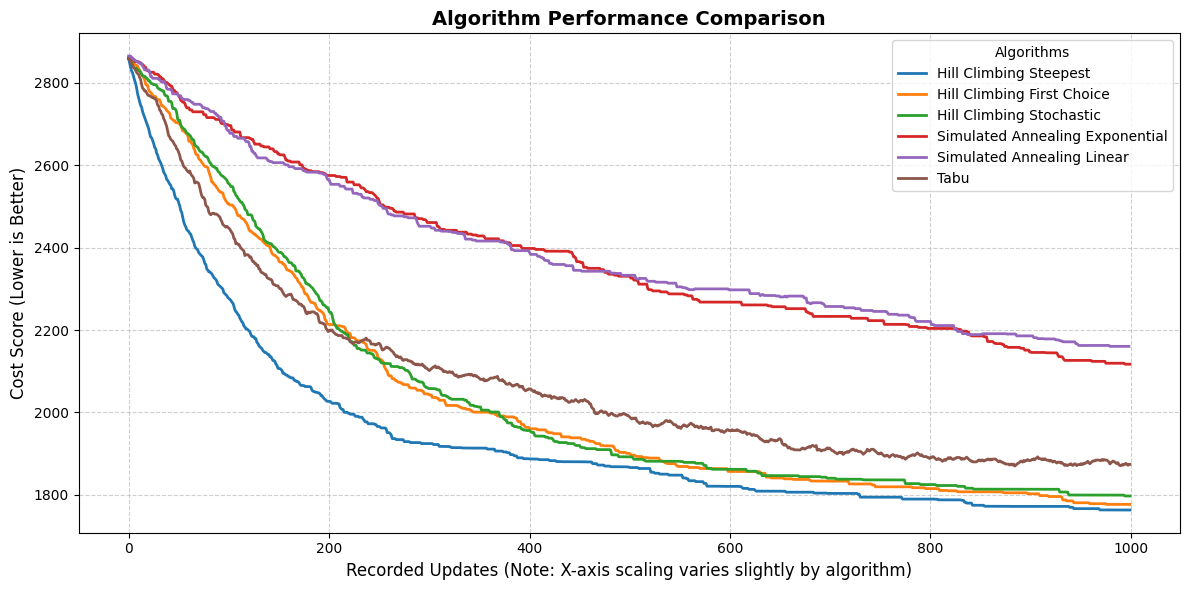

In [11]:
opt = Optimizer()
opt.compare_algorithms(prob, iterations=1000)

Running Hill Climbing Steepest...
Running Hill Climbing First Choice...
Running Hill Climbing Stochastic...
Running Simulated Annealing Exponential...
Running Simulated Annealing Linear...
Running Tabu...


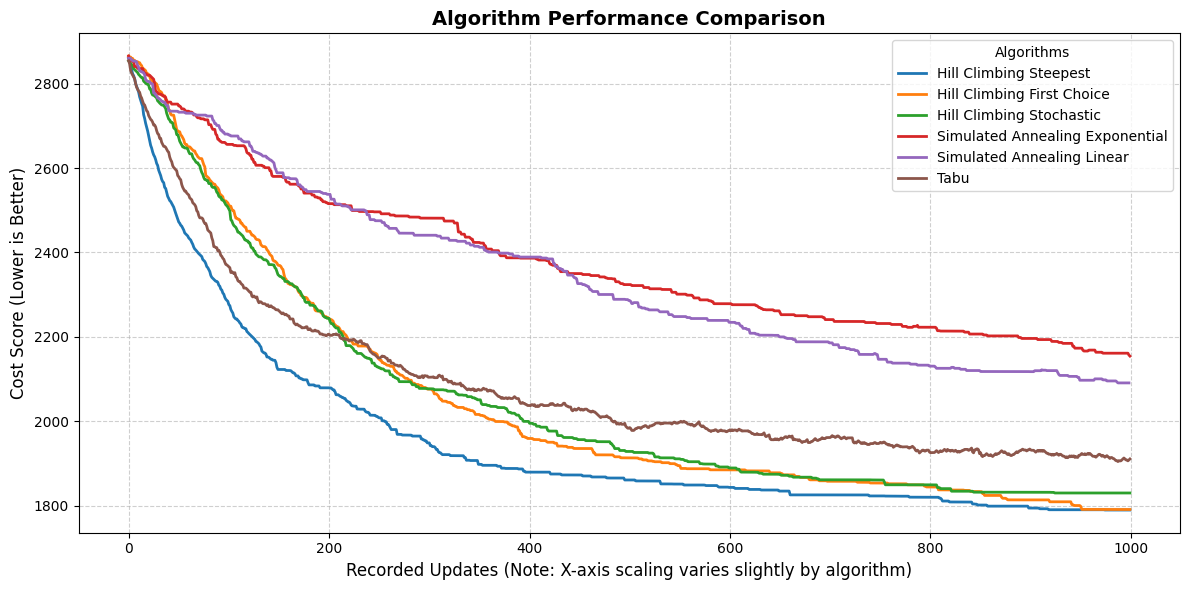

In [12]:
# fine tuned parameeters 
opt = Optimizer()
opt.compare_algorithms(prob, iterations=1000)

Loading problem …
  Events: 469  |  Rooms: 34
Plotting room occupancy heatmap …
  Saved → room_occupancy_heatmap.png
Plotting room utilization heatmap …
  Saved → room_utilization_heatmap.png
Plotting professor schedule heatmap …
  Saved → professor_schedule_heatmap.png
Done.


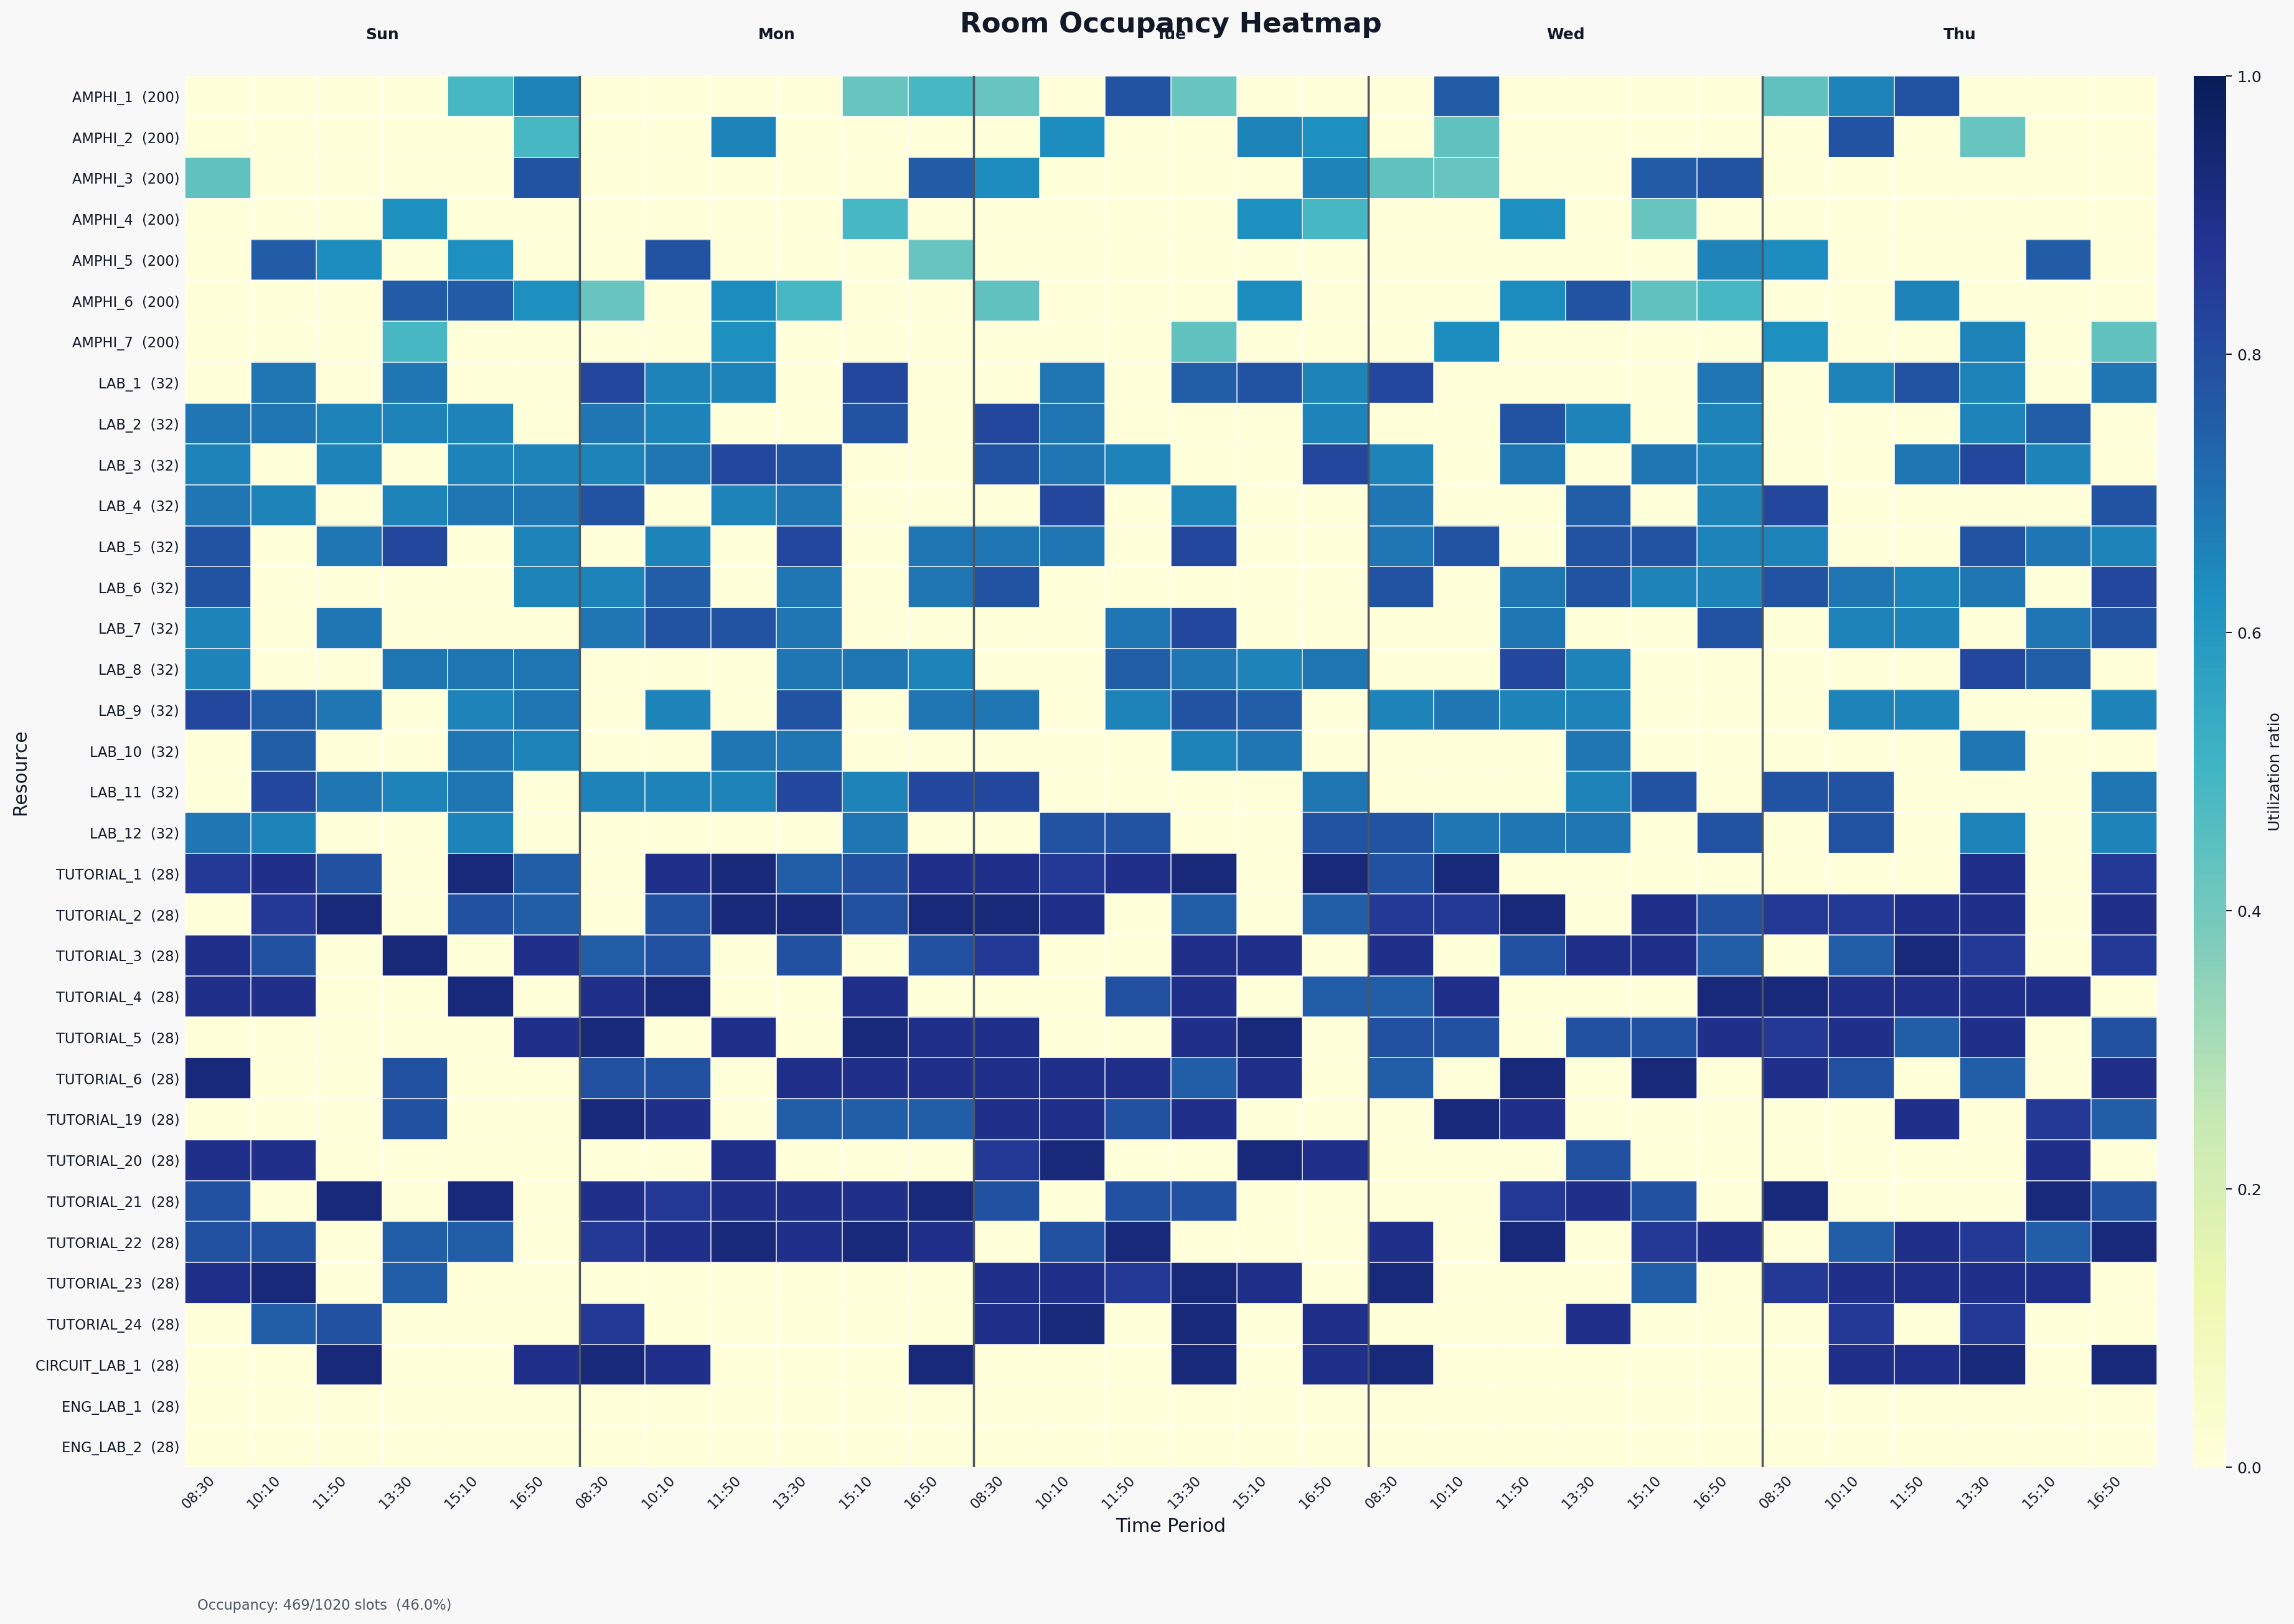

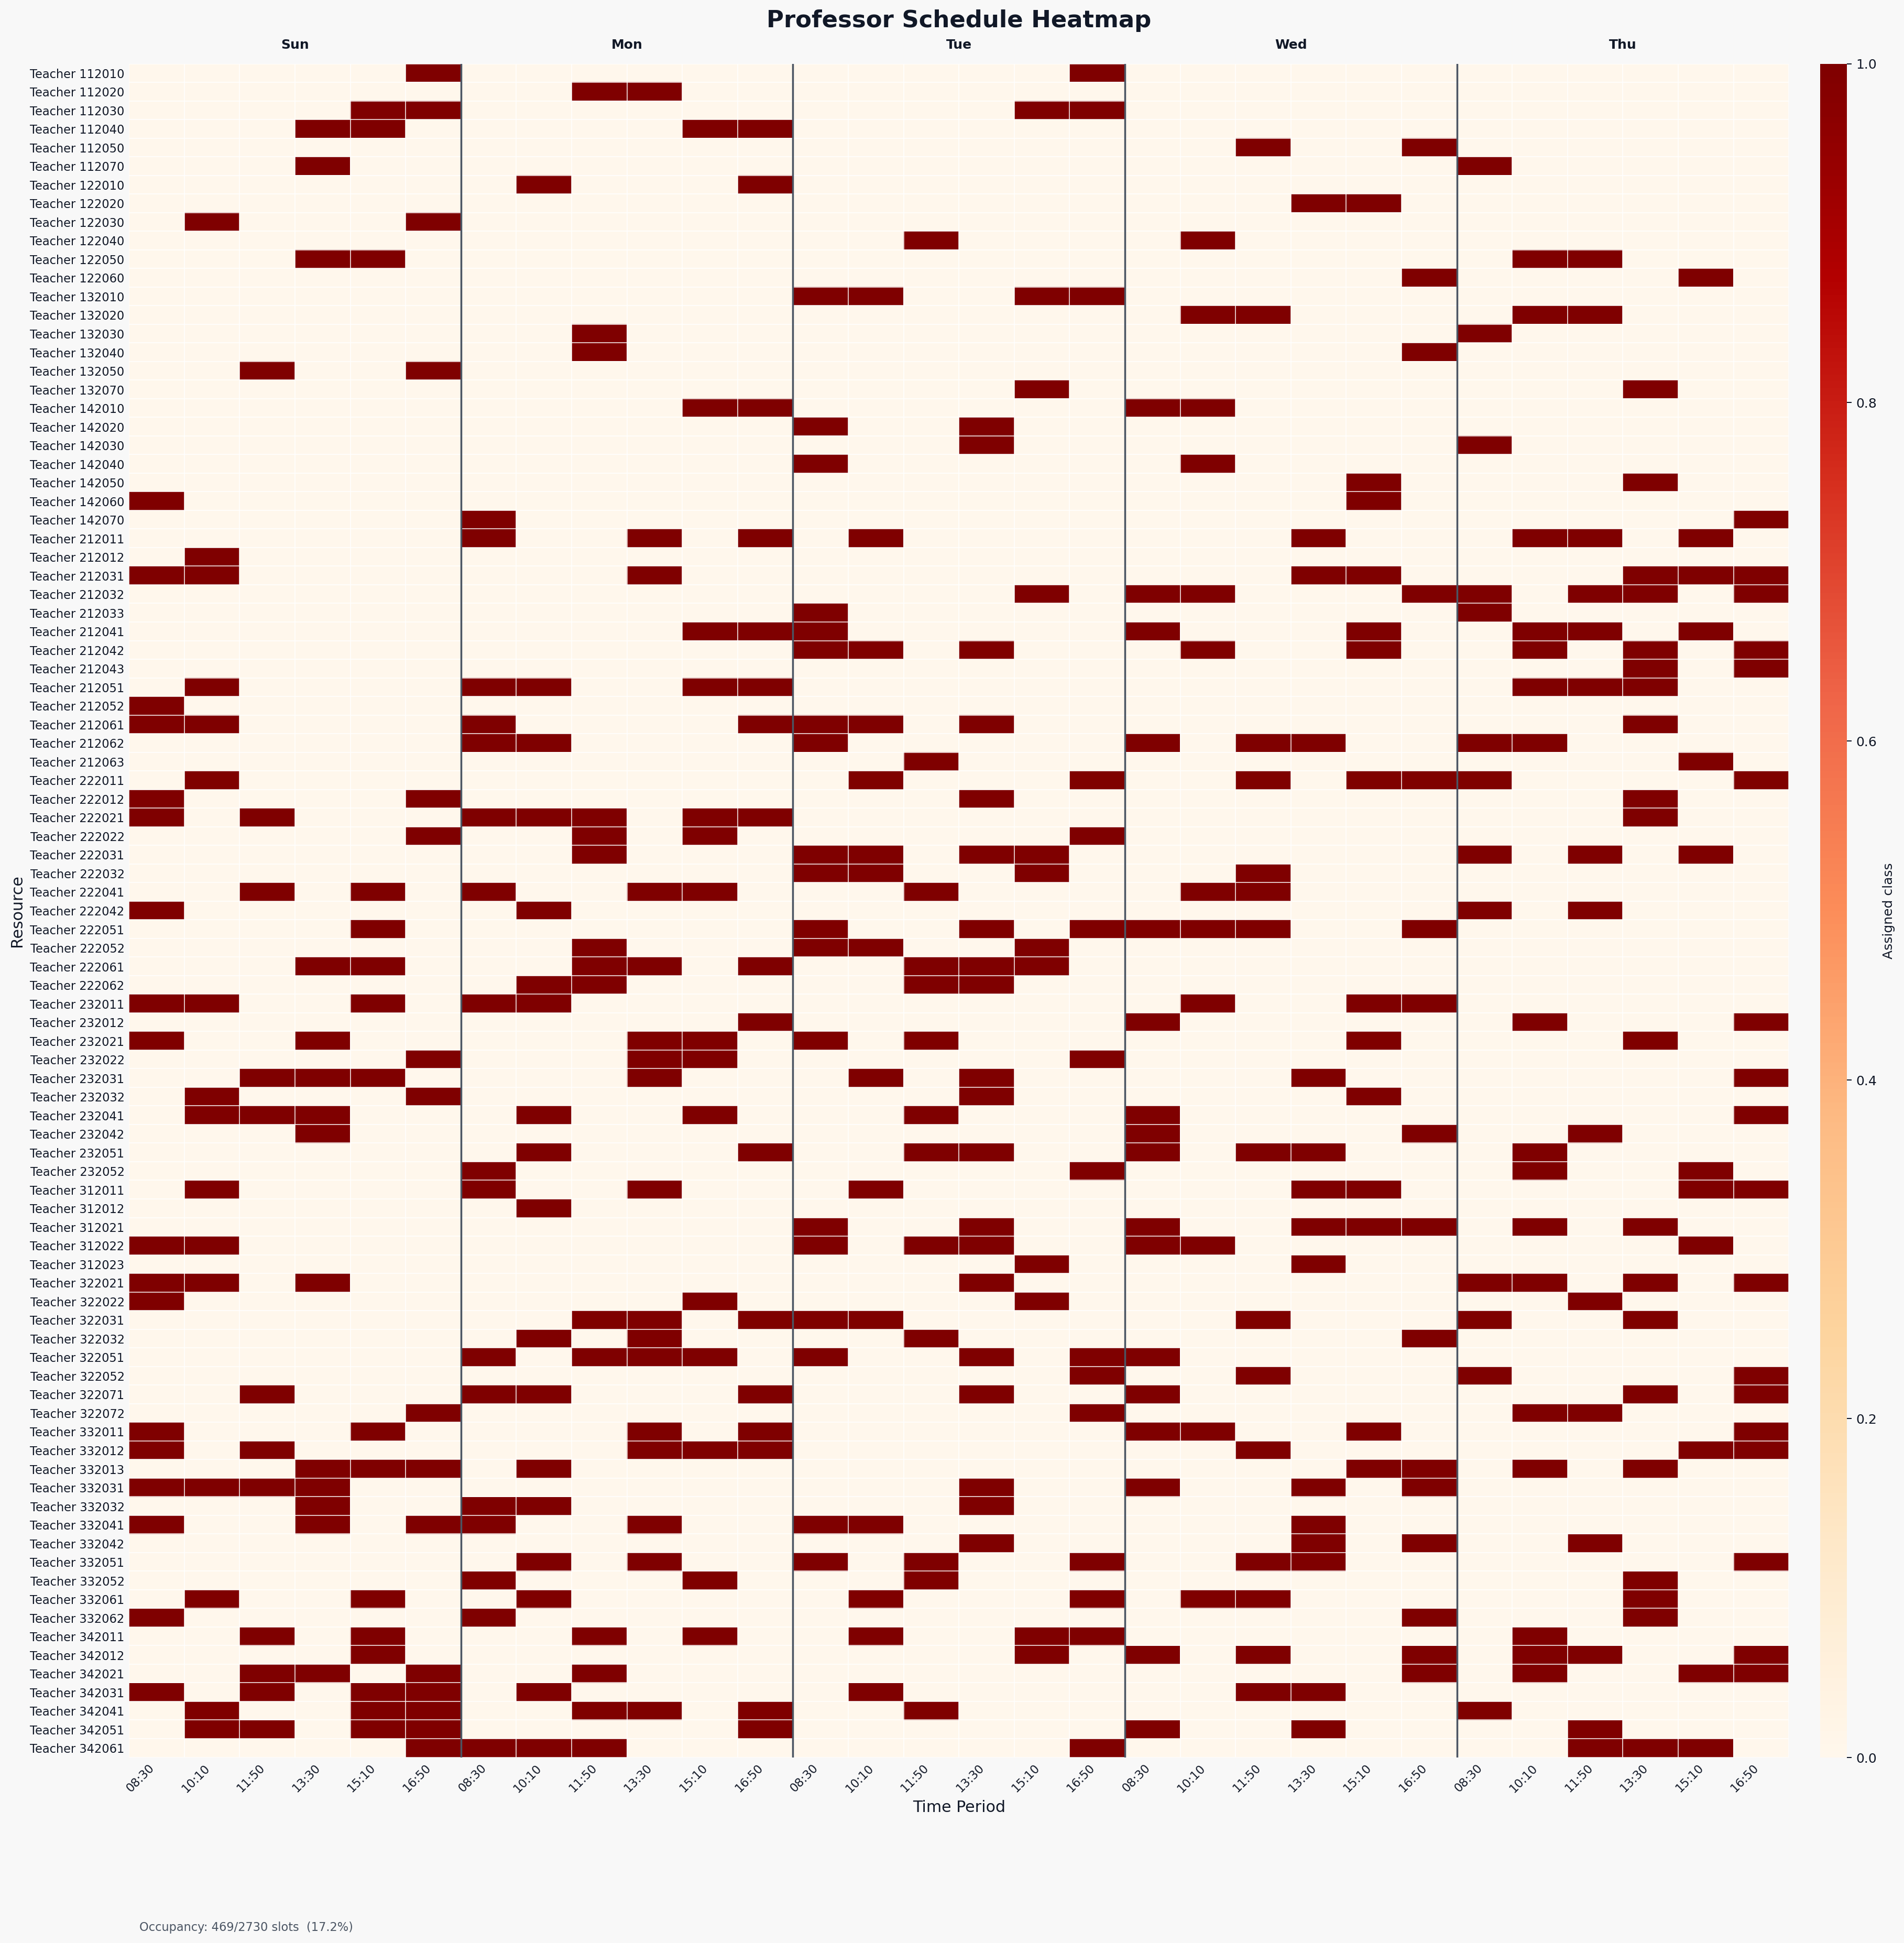

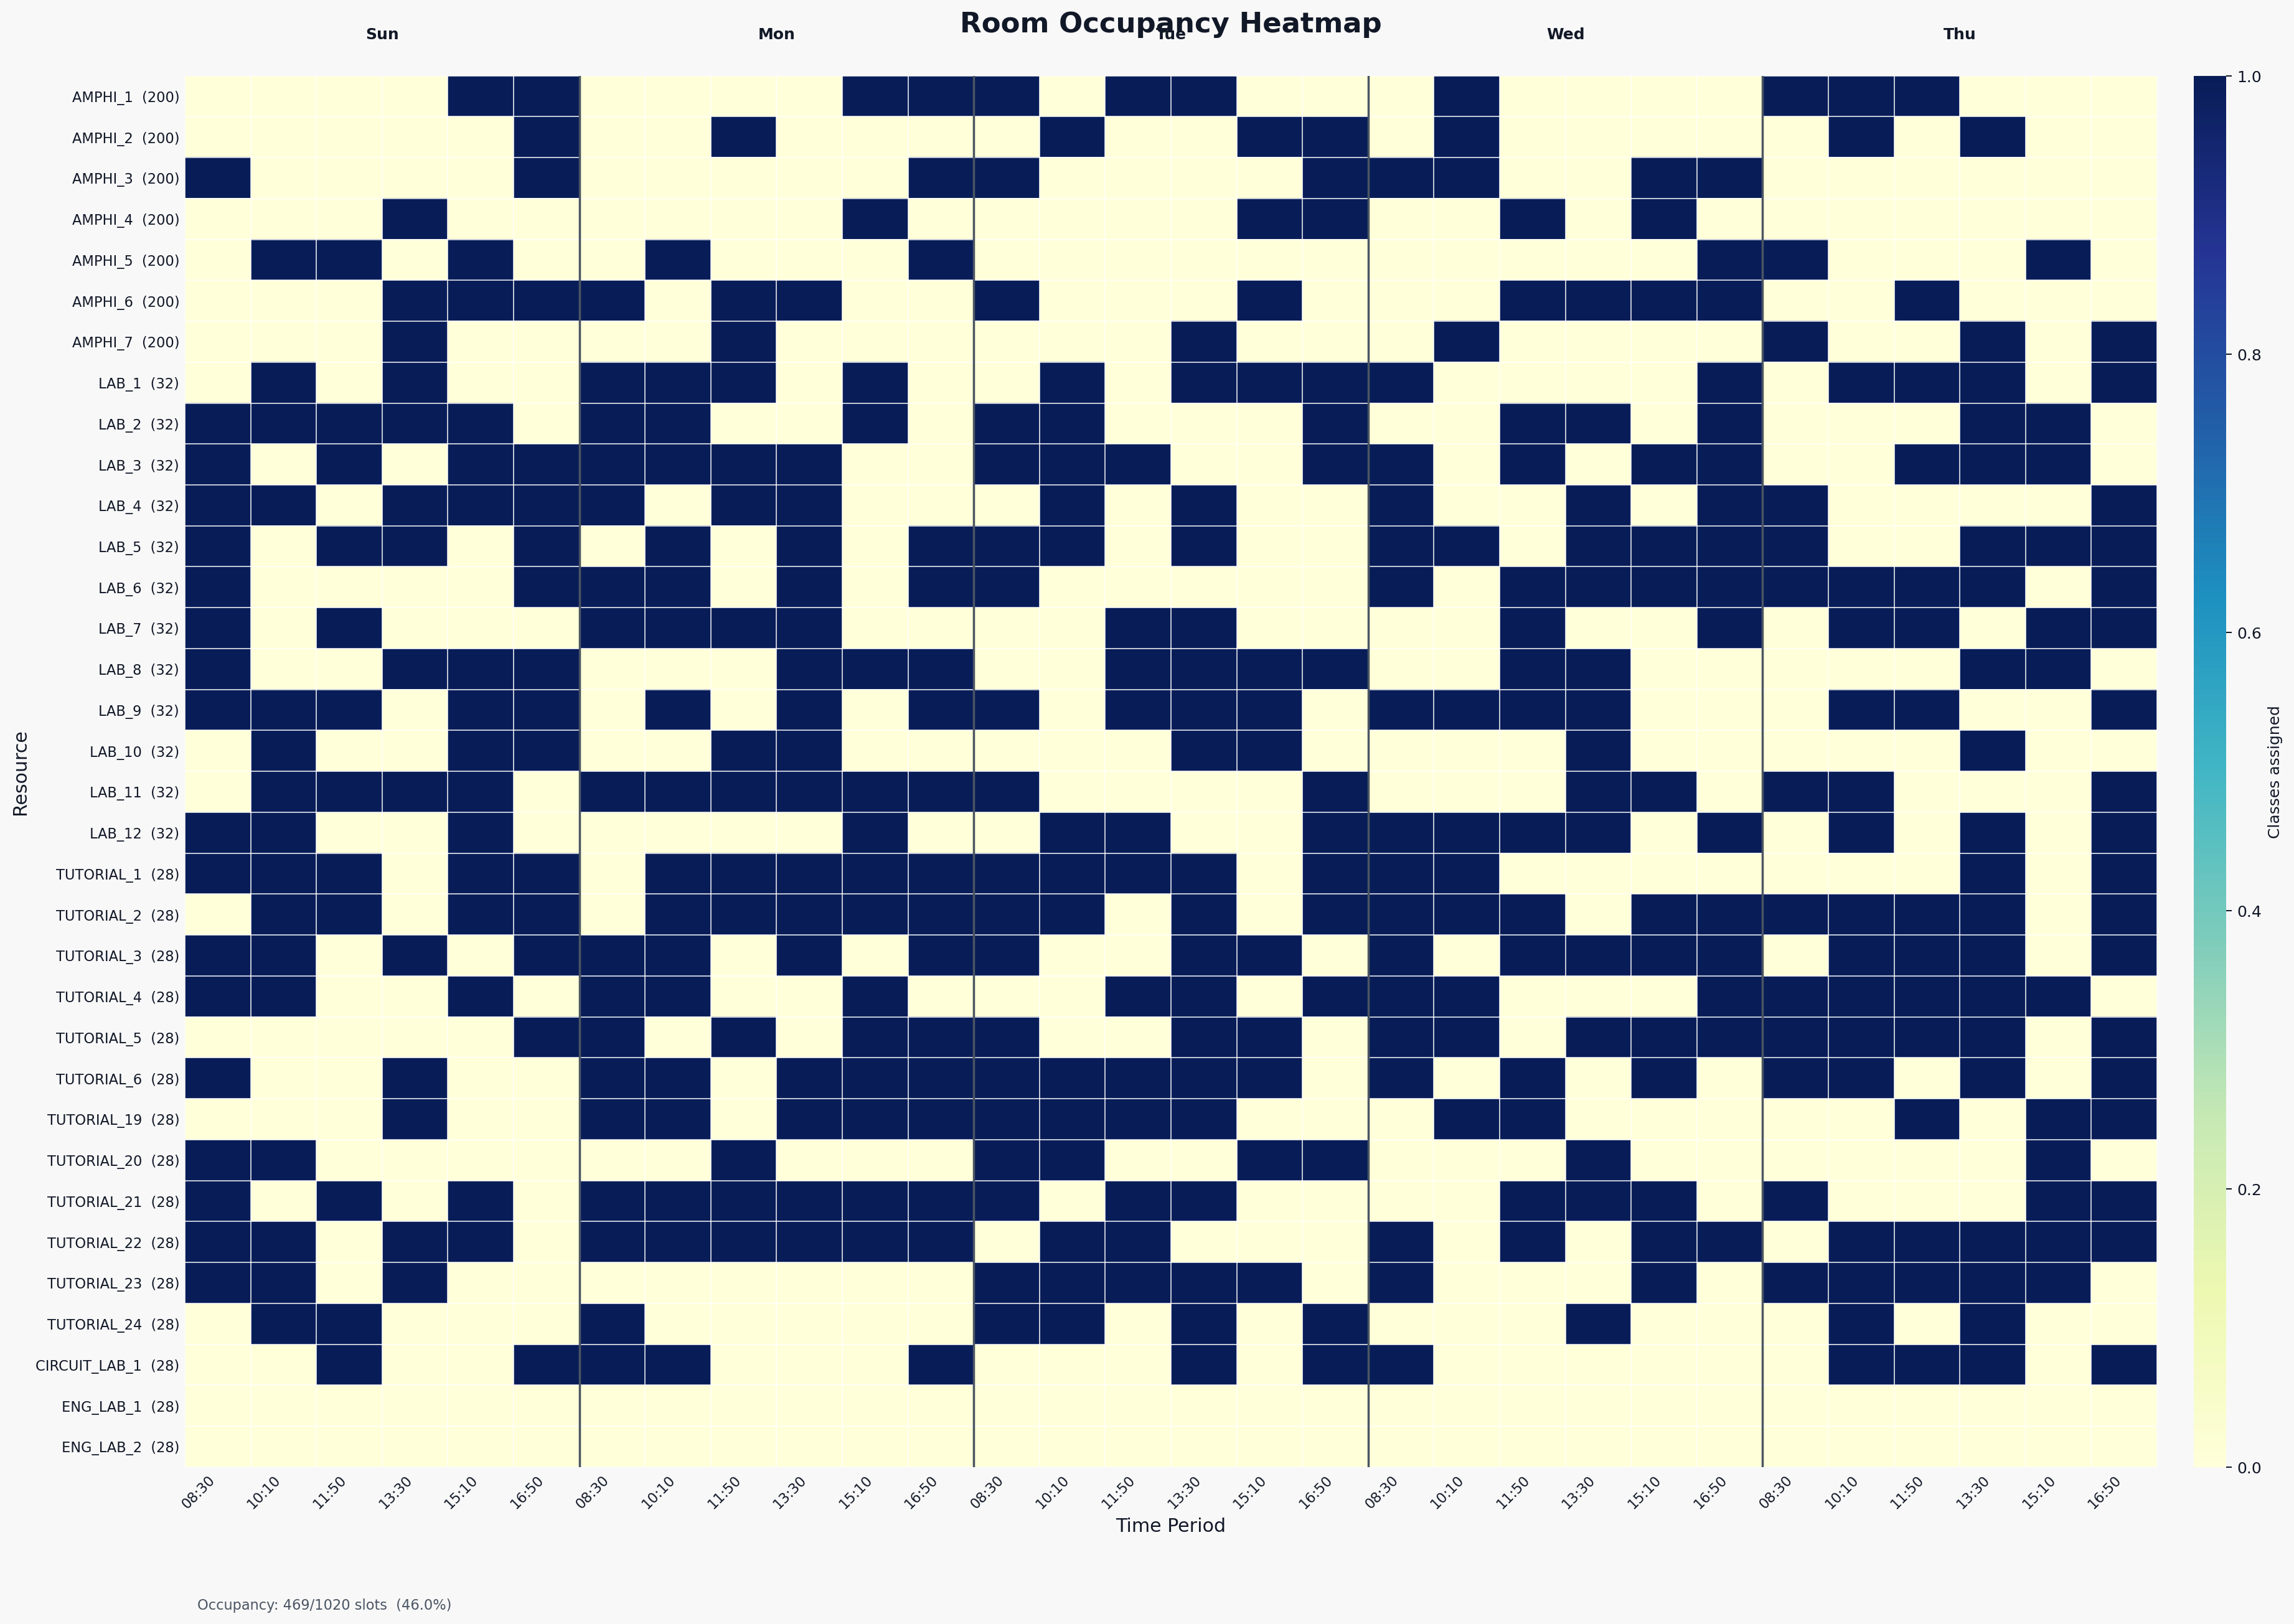

In [10]:
# get the pictures names then render them
res_names = run_vis()
for pic in res_names:
    display(Image(filename=pic))